In [ ]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, Normalizer, normalize
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.feature_extraction.text import TfidfVectorizer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

samples = datasets.load_iris()['data']
species = datasets.load_iris()['target']

# **Unsupervised Leraning**

* Find patterns in the data
* Dimensionality reduction

# ***k-means clustering***



In [ ]:
print(samples[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3) # ใช้ 3 เพราะ label จริงมีสามชนิด
model.fit(samples)
labels = model.predict(samples)
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [ ]:
print(datasets.load_iris()['target'])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


# ***Cluster labels for new samples***

In [ ]:
new_samples = [[ 5.7, 4.4, 1.5, 0.4], [ 6.5, 3. ,5.5, 1.8], [ 5.8, 2.7, 5.1, 1.9]]
new_labels = model.predict(new_samples)
print(new_labels)

[0 2 1]


# ***Scatter plots***
* Scatter plot of sepal length vs. petal length

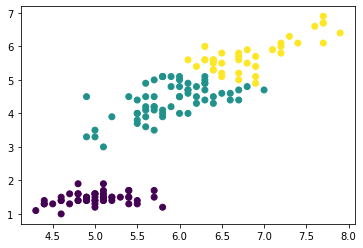

In [ ]:
xs = samples[:,0] # Sepal length
ys = samples[:,2] # Petal length
plt.scatter(xs, ys, c=labels)
plt.show()

### ***Exercise: How many clusters?***

You are given an array `points` of size 300x2, where each row gives the `(x, y)` co-ordinates of a point on a map. Make a scatter plot of these points, and use the scatter plot to guess how many clusters there are.

* Create an array called `xs` that contains the values of points`[:,0]` - that is, column `0` of `points`.

* Create an array called `ys` that contains the values of points`[:,1]` - that is, column `1` of points.

* Make a scatter plot by passing `xs` and `ys` to the `plt.scatter()` function.



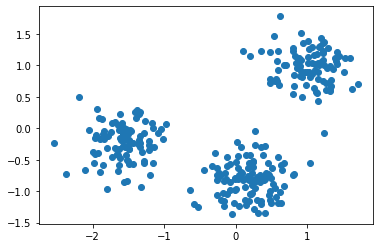

In [ ]:
points = np.array([[ 0.06544649, -0.76866376], [-1.52901547, -0.42953079], [ 1.70993371,  0.69885253], [ 1.16779145,  1.01262638],       [-1.80110088, -0.31861296],       [-1.63567888, -0.02859535],
       [ 1.21990375,  0.74643463],
       [-0.26175155, -0.62492939],
       [-1.61925804, -0.47983949],
       [-1.84329582, -0.16694431],
       [ 1.35999602,  0.94995827],
       [ 0.42291856, -0.7349534 ],
       [-1.68576139,  0.10686728],
       [ 0.90629995,  1.09105162],
       [-1.56478322, -0.84675394],
       [-0.0257849 , -1.18672539],
       [ 0.83027324,  1.14504612],
       [ 1.22450432,  1.35066759],
       [-0.15394596, -0.71704301],
       [ 0.86358809,  1.06824613],
       [-1.43386366, -0.2381297 ],
       [ 0.03844769, -0.74635022],
       [-1.58567922,  0.08499354],
       [ 0.6359888 , -0.58477698],
       [ 0.24417242, -0.53172465],
       [-2.19680359,  0.49473677],
       [ 1.0323503 , -0.55688   ],
       [-0.28858067, -0.39972528],
       [ 0.20597008, -0.80171536],
       [-1.2107308 , -0.34924109],
       [ 1.33423684,  0.7721489 ],
       [ 1.19480152,  1.04788556],
       [ 0.9917477 ,  0.89202008],
       [-1.8356219 , -0.04839732],
       [ 0.08415721, -0.71564326],
       [-1.48970175, -0.19299604],
       [ 0.38782418, -0.82060119],
       [-0.01448044, -0.9779841 ],
       [-2.0521341 , -0.02129125],
       [ 0.10331194, -0.82162781],
       [-0.44189315, -0.65710974],
       [ 1.10390926,  1.02481182],
       [-1.59227759, -0.17374038],
       [-1.47344152, -0.02202853],
       [-1.35514704,  0.22971067],
       [ 0.0412337 , -1.23776622],
       [ 0.4761517 , -1.13672124],
       [ 1.04335676,  0.82345905],
       [-0.07961882, -0.85677394],
       [ 0.87065059,  1.08052841],
       [ 1.40267313,  1.07525119],
       [ 0.80111157,  1.28342825],
       [-0.16527516, -1.23583804],
       [-0.33779221, -0.59194323],
       [ 0.80610749, -0.73752159],
       [-1.43590032, -0.56384446],
       [ 0.54868895, -0.95143829],
       [ 0.46803131, -0.74973907],
       [-1.5137129 , -0.83914323],
       [ 0.9138436 ,  1.51126532],
       [-1.97233903, -0.41155375],
       [ 0.5213406 , -0.88654894],
       [ 0.62759494, -1.18590477],
       [ 0.94163014,  1.35399335],
       [ 0.56994768,  1.07036606],
       [-1.87663382,  0.14745773],
       [ 0.90612186,  0.91084011],
       [-1.37481454,  0.28428395],
       [-1.80564029, -0.96710574],
       [ 0.34307757, -0.79999275],
       [ 0.70380566,  1.00025804],
       [-1.68489862, -0.30564595],
       [ 1.31473221,  0.98614978],
       [ 0.26151216, -0.26069251],
       [ 0.9193121 ,  0.82371485],
       [-1.21795929, -0.20219674],
       [-0.17722723, -1.02665245],
       [ 0.64824862, -0.66822881],
       [ 0.41206786, -0.28783784],
       [ 1.01568202,  1.13481667],
       [ 0.67900254, -0.91489502],
       [-1.05182747, -0.01062376],
       [ 0.61306599,  1.78210384],
       [-1.50219748, -0.52308922],
       [-1.72717293, -0.46173916],
       [-1.60995631, -0.1821007 ],
       [-1.09111021, -0.0781398 ],
       [-0.01046978, -0.80913034],
       [ 0.32782303, -0.80734754],
       [ 1.22038503,  1.1959793 ],
       [-1.33328681, -0.30001937],
       [ 0.87959517,  1.11566491],
       [-1.14829098, -0.30400762],
       [-0.58019755, -1.19996018],
       [-0.01161159, -0.78468854],
       [ 0.17359724, -0.63398145],
       [ 1.32738556,  0.67759969],
       [-1.93467327,  0.30572472],
       [-1.57761893, -0.27726365],
       [ 0.47639   ,  1.21422648],
       [-1.65237509, -0.6803981 ],
       [-0.12609976, -1.04327457],
       [-1.89607082, -0.70085502],
       [ 0.57466899,  0.74878369],
       [-0.16660312, -0.83110295],
       [ 0.8013355 ,  1.22244435],
       [ 1.18455426,  1.4346467 ],
       [ 1.08864428,  0.64667112],
       [-1.61158505,  0.22805725],
       [-1.57512205, -0.09612576],
       [ 0.0721357 , -0.69640328],
       [-1.40054298,  0.16390598],
       [ 1.09607713,  1.16804691],
       [-2.54346204, -0.23089822],
       [-1.34544875,  0.25151126],
       [-1.35478629, -0.19103317],
       [ 0.18368113, -1.15827725],
       [-1.31368677, -0.376357  ],
       [ 0.09990129,  1.22500491],
       [ 1.17225574,  1.30835143],
       [ 0.0865397 , -0.79714371],
       [-0.21053923, -1.13421511],
       [ 0.26496024, -0.94760742],
       [-0.2557591 , -1.06266022],
       [-0.26039757, -0.74774225],
       [-1.91787359,  0.16434571],
       [ 0.93021139,  0.49436331],
       [ 0.44770467, -0.72877918],
       [-1.63802869, -0.58925528],
       [-1.95712763, -0.10125137],
       [ 0.9270337 ,  0.88251423],
       [ 1.25660093,  0.60828073],
       [-1.72818632,  0.08416887],
       [ 0.3499788 , -0.30490298],
       [-1.51696082, -0.50913109],
       [ 0.18763605, -0.55424924],
       [ 0.89609809,  0.83551508],
       [-1.54968857, -0.17114782],
       [ 1.2157457 ,  1.23317728],
       [ 0.20307745, -1.03784906],
       [ 0.84589086,  1.03615273],
       [ 0.53237919,  1.47362884],
       [-0.05319044, -1.36150553],
       [ 1.38819743,  1.11729915],
       [ 1.00696304,  1.0367721 ],
       [ 0.56681869, -1.09637176],
       [ 0.86888296,  1.05248874],
       [-1.16286609, -0.55875245],
       [ 0.27717768, -0.83844015],
       [ 0.16563267, -0.80306607],
       [ 0.38263303, -0.42683241],
       [ 1.14519807,  0.89659026],
       [ 0.81455857,  0.67533667],
       [-1.8603152 , -0.09537561],
       [ 0.965641  ,  0.90295579],
       [-1.49897451, -0.33254044],
       [-0.1335489 , -0.80727582],
       [ 0.12541527, -1.13354906],
       [ 1.06062436,  1.28816358],
       [-1.49154578, -0.2024641 ],
       [ 1.16189032,  1.28819877],
       [ 0.54282033,  0.75203524],
       [ 0.89221065,  0.99211624],
       [-1.49932011, -0.32430667],
       [ 0.3166647 , -1.34482915],
       [ 0.13972469, -1.22097448],
       [-1.5499724 , -0.10782584],
       [ 1.23846858,  1.37668804],
       [ 1.25558954,  0.72026098],
       [ 0.25558689, -1.28529763],
       [ 0.45168933, -0.55952093],
       [ 1.06202057,  1.03404604],
       [ 0.67451908, -0.54970299],
       [ 0.22759676, -1.02729468],
       [-1.45835281, -0.04951074],
       [ 0.23273501, -0.70849262],
       [ 1.59679589,  1.11395076],
       [ 0.80476105,  0.544627  ],
       [ 1.15492521,  1.04352191],
       [ 0.59632776, -1.19142897],
       [ 0.02839068, -0.43829366],
       [ 1.13451584,  0.5632633 ],
       [ 0.21576204, -1.04445753],
       [ 1.41048987,  1.02830719],
       [ 1.12289302,  0.58029441],
       [ 0.25200688, -0.82588436],
       [-1.28566081, -0.07390909],
       [ 1.52849815,  1.11822469],
       [-0.23907858, -0.70541972],
       [-0.25792784, -0.81825035],
       [ 0.59367818, -0.45239915],
       [ 0.07931909, -0.29233213],
       [-1.27256815,  0.11630577],
       [ 0.66930129,  1.00731481],
       [ 0.34791546, -1.20822877],
       [-2.11283993, -0.66897935],
       [-1.6293824 , -0.32718222],
       [-1.53819139, -0.01501972],
       [-0.11988545, -0.6036339 ],
       [-1.54418956, -0.30389844],
       [ 0.30026614, -0.77723173],
       [ 0.00935449, -0.53888192],
       [-1.33424393, -0.11560431],
       [ 0.47504489,  0.78421384],
       [ 0.59313264,  1.232239  ],
       [ 0.41370369, -1.35205857],
       [ 0.55840948,  0.78831053],
       [ 0.49855018, -0.789949  ],
       [ 0.35675809, -0.81038693],
       [-1.86197825, -0.59071305],
       [-1.61977671, -0.16076687],
       [ 0.80779295, -0.73311294],
       [ 1.62745775,  0.62787163],
       [-1.56993593, -0.08467567],
       [ 1.02558561,  0.89383302],
       [ 0.24293461, -0.6088253 ],
       [ 1.23130242,  1.00262186],
       [-1.9651013 , -0.15886289],
       [ 0.42795032, -0.70384432],
       [-1.58306818, -0.19431923],
       [-1.57195922,  0.01413469],
       [-0.98145373,  0.06132285],
       [-1.48637844, -0.5746531 ],
       [ 0.98745828,  0.69188053],
       [ 1.28619721,  1.28128821],
       [ 0.85850596,  0.95541481],
       [ 0.19028286, -0.82112942],
       [ 0.26561046, -0.04255239],
       [-1.61897897,  0.00862372],
       [ 0.24070183, -0.52664209],
       [ 1.15220993,  0.43916694],
       [-1.21967812, -0.2580313 ],
       [ 0.33412533, -0.86117761],
       [ 0.17131003, -0.75638965],
       [-1.19828397, -0.73744665],
       [-0.12245932, -0.45648879],
       [ 1.51200698,  0.88825741],
       [ 1.10338866,  0.92347479],
       [ 1.30972095,  0.59066989],
       [ 0.19964876,  1.14855889],
       [ 0.81460515,  0.84538972],
       [-1.6422739 , -0.42296206],
       [ 0.01224351, -0.21247816],
       [ 0.33709102, -0.74618065],
       [ 0.47301054,  0.72712075],
       [ 0.34706626,  1.23033757],
       [-0.00393279, -0.97209694],
       [-1.64303119,  0.05276337],
       [ 1.44649625,  1.14217033],
       [-1.93030087, -0.40026146],
       [-2.37296135, -0.72633645],
       [ 0.45860122, -1.06048953],
       [ 0.4896361 , -1.18928313],
       [-1.02335902, -0.17520578],
       [-1.32761107, -0.93963549],
       [-1.50987909, -0.09473658],
       [ 0.02723057, -0.79870549],
       [ 1.0169412 ,  1.26461701],
       [ 0.47733527, -0.9898471 ],
       [-1.27784224, -0.547416  ],
       [ 0.49898802, -0.6237259 ],
       [ 1.06004731,  0.86870008],
       [ 1.00207501,  1.38293512],
       [ 1.31161394,  0.62833956],
       [ 1.13428443,  1.18346542],
       [ 1.27671346,  0.96632878],
       [-0.63342885, -0.97768251],
       [ 0.12698779, -0.93142317],
       [-1.34510812, -0.23754226],
       [-0.53162278, -1.25153594],
       [ 0.21959934, -0.90269938],
       [-1.78997479, -0.12115748],
       [ 1.23197473, -0.07453764],
       [ 1.4163536 ,  1.21551752],
       [-1.90280976, -0.1638976 ],
       [-0.22440081, -0.75454248],
       [ 0.59559412,  0.92414553],
       [ 1.21930773,  1.08175284],
       [-1.99427535, -0.37587799],
       [-1.27818474, -0.52454551],
       [ 0.62352689, -1.01430108],
       [ 0.14024251, -0.428266  ],
       [-0.16145713, -1.16359731],
       [-1.74795865, -0.06033101],
       [-1.16659791,  0.0902393 ],
       [ 0.41110408, -0.8084249 ],
       [ 1.14757168,  0.77804528],
       [-1.65590748, -0.40105446],
       [-1.15306865,  0.00858699],
       [ 0.60892121,  0.68974833],
       [-0.08434138, -0.97615256],
       [ 0.19170053, -0.42331438],
       [ 0.29663162, -1.13357399],
       [-1.36893628, -0.25052124],
       [-0.08037807, -0.56784155],
       [ 0.35695011, -1.15064408],
       [ 0.02482179, -0.63594828],
       [-1.49075558, -0.2482507 ],
       [-1.408588  ,  0.25635431],
       [-1.98274626, -0.54584475]])
new_points = np.array([[ 4.00233332e-01, -1.26544471e+00],
       [ 8.03230370e-01,  1.28260167e+00],
       [-1.39507552e+00,  5.57292921e-02],
       [-3.41192677e-01, -1.07661994e+00],
       [ 1.54781747e+00,  1.40250049e+00],
       [ 2.45032018e-01, -4.83442328e-01],
       [ 1.20706886e+00,  8.88752605e-01],
       [ 1.25132628e+00,  1.15555395e+00],
       [ 1.81004415e+00,  9.65530731e-01],
       [-1.66963401e+00, -3.08103509e-01],
       [-7.17482105e-02, -9.37939700e-01],
       [ 6.82631927e-01,  1.10258160e+00],
       [ 1.09039598e+00,  1.43899529e+00],
       [-1.67645414e+00, -5.04557049e-01],
       [-1.84447804e+00,  4.52539544e-02],
       [ 1.24234851e+00,  1.02088661e+00],
       [-1.86147041e+00,  6.38645811e-03],
       [-1.46044943e+00,  1.53252383e-01],
       [ 4.98981817e-01,  8.98006058e-01],
       [ 9.83962244e-01,  1.04369375e+00],
       [-1.83136742e+00, -1.63632835e-01],
       [ 1.30622617e+00,  1.07658717e+00],
       [ 3.53420328e-01, -7.51320218e-01],
       [ 1.13957970e+00,  1.54503860e+00],
       [ 2.93995694e-01, -1.26135005e+00],
       [-1.14558225e+00, -3.78709636e-02],
       [ 1.18716105e+00,  6.00240663e-01],
       [-2.23211946e+00,  2.30475094e-01],
       [-1.28320430e+00, -3.93314568e-01],
       [ 4.94296696e-01, -8.83972009e-01],
       [ 6.31834930e-02, -9.11952228e-01],
       [ 9.35759539e-01,  8.66820685e-01],
       [ 1.58014721e+00,  1.03788392e+00],
       [ 1.06304960e+00,  1.02706082e+00],
       [-1.39732536e+00, -5.05162249e-01],
       [-1.09935240e-01, -9.08113619e-01],
       [ 1.17346758e+00,  9.47501092e-01],
       [ 9.20084511e-01,  1.45767672e+00],
       [ 5.82658956e-01, -9.00086832e-01],
       [ 9.52772328e-01,  8.99042386e-01],
       [-1.37266956e+00, -3.17878215e-02],
       [ 2.12706760e-02, -7.07614194e-01],
       [ 3.27049052e-01, -5.55998107e-01],
       [-1.71590267e+00,  2.15222266e-01],
       [ 5.12516209e-01, -7.60128245e-01],
       [ 1.13023469e+00,  7.22451122e-01],
       [-1.43074310e+00, -3.42787511e-01],
       [-1.82724625e+00,  1.17657775e-01],
       [ 1.41801350e+00,  1.11455080e+00],
       [ 1.26897304e+00,  1.41925971e+00],
       [ 8.04076494e-01,  1.63988557e+00],
       [ 8.34567752e-01,  1.09956689e+00],
       [-1.24714732e+00, -2.23522320e-01],
       [-1.29422537e+00,  8.18770024e-02],
       [-2.27378316e-01, -4.13331387e-01],
       [ 2.18830387e-01, -4.68183120e-01],
       [-1.22593414e+00,  2.55599147e-01],
       [-1.31294033e+00, -4.28892070e-01],
       [-1.33532382e+00,  6.52053776e-01],
       [-3.01100233e-01, -1.25156451e+00],
       [ 2.02778356e-01, -9.05277445e-01],
       [ 1.01357784e+00,  1.12378981e+00],
       [ 8.18324394e-01,  8.60841257e-01],
       [ 1.26181556e+00,  1.46613744e+00],
       [ 4.64867724e-01, -7.97212459e-01],
       [ 3.60908898e-01,  8.44106720e-01],
       [-2.15098310e+00, -3.69583937e-01],
       [ 1.05005281e+00,  8.74181364e-01],
       [ 1.06580074e-01, -7.49268153e-01],
       [-1.73945723e+00,  2.52183577e-01],
       [-1.12017687e-01, -6.52469788e-01],
       [ 5.16618951e-01, -6.41267582e-01],
       [ 3.26621787e-01, -8.80608015e-01],
       [ 1.09017759e+00,  1.10952558e+00],
       [ 3.64459576e-01, -6.94215622e-01],
       [-1.90779318e+00,  1.87383674e-01],
       [-1.95601829e+00,  1.39959126e-01],
       [ 3.18541701e-01, -4.05271704e-01],
       [ 7.36512699e-01,  1.76416255e+00],
       [-1.44175162e+00, -5.72320429e-02],
       [ 3.21757168e-01, -5.34283821e-01],
       [-1.37317305e+00,  4.64484644e-02],
       [ 6.87225910e-02, -1.10522944e+00],
       [ 9.59314218e-01,  6.52316210e-01],
       [-1.62641919e+00, -5.62423280e-01],
       [ 1.06788305e+00,  7.29260482e-01],
       [-1.79643547e+00, -9.88307418e-01],
       [-9.88628377e-02, -6.81198092e-02],
       [-1.05135700e-01,  1.17022143e+00],
       [ 8.79964699e-01,  1.25340317e+00],
       [ 9.80753407e-01,  1.15486539e+00],
       [-8.33224966e-02, -9.24844368e-01],
       [ 8.48759673e-01,  1.09397425e+00],
       [ 1.32941649e+00,  1.13734563e+00],
       [ 3.23788068e-01, -7.49732451e-01],
       [-1.52610970e+00, -2.49016929e-01],
       [-1.48598116e+00, -2.68828608e-01],
       [-1.80479553e+00,  1.87052700e-01],
       [-2.01907347e+00, -4.49511651e-01],
       [ 2.87202402e-01, -6.55487415e-01],
       [ 8.22295102e-01,  1.38443234e+00],
       [-3.56997036e-02, -8.01825807e-01],
       [-1.66955440e+00, -1.38258505e-01],
       [-1.78226821e+00,  2.93353033e-01],
       [ 7.25837138e-01, -6.23374024e-01],
       [ 3.88432593e-01, -7.61283497e-01],
       [ 1.49002783e+00,  7.95678671e-01],
       [ 6.55423228e-04, -7.40580702e-01],
       [-1.34533116e+00, -4.75629937e-01],
       [-8.03845106e-01, -3.09943013e-01],
       [-2.49041295e-01, -1.00662418e+00],
       [-1.41095118e+00, -7.06744127e-02],
       [-1.75119594e+00, -3.00491336e-01],
       [-1.27942724e+00,  1.73774600e-01],
       [ 3.35028183e-01,  6.24761151e-01],
       [ 1.16819649e+00,  1.18902251e+00],
       [ 7.15210457e-01,  9.26077419e-01],
       [ 1.30057278e+00,  9.16349565e-01],
       [-1.21697008e+00,  1.10039477e-01],
       [-1.70707935e+00, -5.99659536e-02],
       [ 1.20730655e+00,  1.05480463e+00],
       [ 1.86896009e-01, -9.58047234e-01],
       [ 8.03463471e-01,  3.86133140e-01],
       [-1.73486790e+00, -1.49831913e-01],
       [ 1.31261499e+00,  1.11802982e+00],
       [ 4.04993148e-01, -5.10900347e-01],
       [-1.93267968e+00,  2.20764694e-01],
       [ 6.56004799e-01,  9.61887161e-01],
       [-1.40588215e+00,  1.17134403e-01],
       [-1.74306264e+00, -7.47473959e-02],
       [ 5.43745412e-01,  1.47209224e+00],
       [-1.97331669e+00, -2.27124493e-01],
       [ 1.53901171e+00,  1.36049081e+00],
       [-1.48323452e+00, -4.90302063e-01],
       [ 3.86748484e-01, -1.26173400e+00],
       [ 1.17015716e+00,  1.18549415e+00],
       [-8.05381721e-02, -3.21923627e-01],
       [-6.82273156e-02, -8.52825887e-01],
       [ 7.13500028e-01,  1.27868520e+00],
       [-1.85014378e+00, -5.03490558e-01],
       [ 6.36085266e-02, -1.41257040e+00],
       [ 1.52966062e+00,  9.66056572e-01],
       [ 1.62165714e-01, -1.37374843e+00],
       [-3.23474497e-01, -7.06620269e-01],
       [-1.51768993e+00,  1.87658302e-01],
       [ 8.88895911e-01,  7.62237161e-01],
       [ 4.83164032e-01,  8.81931869e-01],
       [-5.52997766e-02, -7.11305016e-01],
       [-1.57966441e+00, -6.29220313e-01],
       [ 5.51308645e-02, -8.47206763e-01],
       [-2.06001582e+00,  5.87697787e-02],
       [ 1.11810855e+00,  1.30254175e+00],
       [ 4.87016164e-01, -9.90143937e-01],
       [-1.65518042e+00, -1.69386383e-01],
       [-1.44349738e+00,  1.90299243e-01],
       [-1.70074547e-01, -8.26736022e-01],
       [-1.82433979e+00, -3.07814626e-01],
       [ 1.03093485e+00,  1.26457691e+00],
       [ 1.64431169e+00,  1.27773115e+00],
       [-1.47617693e+00,  2.60783872e-02],
       [ 1.00953067e+00,  1.14270181e+00],
       [-1.45285636e+00, -2.55216207e-01],
       [-1.74092917e+00, -8.34443177e-02],
       [ 1.22038299e+00,  1.28699961e+00],
       [ 9.16925397e-01,  7.32070275e-01],
       [-1.60754185e-03, -7.26375571e-01],
       [ 8.93841238e-01,  8.41146643e-01],
       [ 6.33791961e-01,  1.00915134e+00],
       [-1.47927075e+00, -6.99781936e-01],
       [ 5.44799374e-02, -1.06441970e+00],
       [-1.51935568e+00, -4.89276929e-01],
       [ 2.89939026e-01, -7.73145523e-01],
       [-9.68154061e-03, -1.13302207e+00],
       [ 1.13474639e+00,  9.71541744e-01],
       [ 5.36421406e-01, -8.47906388e-01],
       [ 1.14759864e+00,  6.89915205e-01],
       [ 5.73291902e-01,  7.90802710e-01],
       [ 2.12377397e-01, -6.07569808e-01],
       [ 5.26579548e-01, -8.15930264e-01],
       [-2.01831641e+00,  6.78650740e-02],
       [-2.35512624e-01, -1.08205132e+00],
       [ 1.59274780e-01, -6.00717261e-01],
       [ 2.28120356e-01, -1.16003549e+00],
       [-1.53658378e+00,  8.40798808e-02],
       [ 1.13954609e+00,  6.31782001e-01],
       [ 1.01119255e+00,  1.04360805e+00],
       [-1.42039867e-01, -4.81230337e-01],
       [-2.23120182e+00,  8.49162905e-02],
       [ 1.25554811e-01, -1.01794793e+00],
       [-1.72493509e+00, -6.94426177e-01],
       [-1.60434630e+00,  4.45550868e-01],
       [ 7.37153979e-01,  9.26560744e-01],
       [ 6.72905271e-01,  1.13366030e+00],
       [ 1.20066456e+00,  7.26273093e-01],
       [ 7.58747209e-02, -9.83378326e-01],
       [ 1.28783262e+00,  1.18088601e+00],
       [ 1.06521930e+00,  1.00714746e+00],
       [ 1.05871698e+00,  1.12956519e+00],
       [-1.12643410e+00,  1.66787744e-01],
       [-1.10157218e+00, -3.64137806e-01],
       [ 2.35118217e-01, -1.39769949e-01],
       [ 1.13853795e+00,  1.01018519e+00],
       [ 5.31205654e-01, -8.81990792e-01],
       [ 4.33085936e-01, -7.64059042e-01],
       [-4.48926156e-03, -1.30548411e+00],
       [-1.76348589e+00, -4.97430739e-01],
       [ 1.36485681e+00,  5.83404699e-01],
       [ 5.66923900e-01,  1.51391963e+00],
       [ 1.35736826e+00,  6.70915318e-01],
       [ 1.07173397e+00,  6.11990884e-01],
       [ 1.00106915e+00,  8.93815326e-01],
       [ 1.33091007e+00,  8.79773879e-01],
       [-1.79603740e+00, -3.53883973e-02],
       [-1.27222979e+00,  4.00156642e-01],
       [ 8.47480603e-01,  1.17032364e+00],
       [-1.50989129e+00, -7.12318330e-01],
       [-1.24953576e+00, -5.57859730e-01],
       [-1.27717973e+00, -5.99350550e-01],
       [-1.81946743e+00,  7.37057673e-01],
       [ 1.19949867e+00,  1.56969386e+00],
       [-1.25543847e+00, -2.33892826e-01],
       [-1.63052058e+00,  1.61455865e-01],
       [ 1.10611305e+00,  7.39698224e-01],
       [ 6.70193192e-01,  8.70567001e-01],
       [ 3.69670156e-01, -6.94645306e-01],
       [-1.26362293e+00, -6.99249285e-01],
       [-3.66687507e-01, -1.35310260e+00],
       [ 2.44032147e-01, -6.59470793e-01],
       [-1.27679142e+00, -4.85453412e-01],
       [ 3.77473612e-02, -6.99251605e-01],
       [-2.19148539e+00, -4.91199500e-01],
       [-2.93277777e-01, -5.89488212e-01],
       [-1.65737397e+00, -2.98337786e-01],
       [ 7.36638861e-01,  5.78037057e-01],
       [ 1.13709081e+00,  1.30119754e+00],
       [-1.44146601e+00,  3.13934680e-02],
       [ 5.92360708e-01,  1.22545114e+00],
       [ 6.51719414e-01,  4.92674894e-01],
       [ 5.94559139e-01,  8.25637315e-01],
       [-1.87900722e+00, -5.21899626e-01],
       [ 2.15225041e-01, -1.28269851e+00],
       [ 4.99145965e-01, -6.70268634e-01],
       [-1.82954176e+00, -3.39269731e-01],
       [ 7.92721403e-01,  1.33785606e+00],
       [ 9.54363372e-01,  9.80396626e-01],
       [-1.35359846e+00,  1.03976340e-01],
       [ 1.05595062e+00,  8.07031927e-01],
       [-1.94311010e+00, -1.18976964e-01],
       [-1.39604137e+00, -3.10095976e-01],
       [ 1.28977624e+00,  1.01753365e+00],
       [-1.59503139e+00, -5.40574609e-01],
       [-1.41994046e+00, -3.81032569e-01],
       [-2.35569801e-02, -1.10133702e+00],
       [-1.26038568e+00, -6.93273886e-01],
       [ 9.60215981e-01, -8.11553694e-01],
       [ 5.51803308e-01, -1.01793176e+00],
       [ 3.70185085e-01, -1.06885468e+00],
       [ 8.25529207e-01,  8.77007060e-01],
       [-1.87032595e+00,  2.87507199e-01],
       [-1.56260769e+00, -1.89196712e-01],
       [-1.26346548e+00, -7.74725237e-01],
       [-6.33800421e-02, -7.59400611e-01],
       [ 8.85298280e-01,  8.85620519e-01],
       [-1.43324686e-01, -1.16083678e+00],
       [-1.83908725e+00, -3.26655515e-01],
       [ 2.74709229e-01, -1.04546829e+00],
       [-1.45703573e+00, -2.91842036e-01],
       [-1.59048842e+00,  1.66063031e-01],
       [ 9.25549284e-01,  7.41406406e-01],
       [ 1.97245469e-01, -7.80703225e-01],
       [ 2.88401697e-01, -8.32425551e-01],
       [ 7.24141618e-01, -7.99149200e-01],
       [-1.62658639e+00, -1.80005543e-01],
       [ 5.84481588e-01,  1.13195640e+00],
       [ 1.02146732e+00,  4.59657799e-01],
       [ 8.65050554e-01,  9.57714887e-01],
       [ 3.98717766e-01, -1.24273147e+00],
       [ 8.62234892e-01,  1.10955561e+00],
       [-1.35999430e+00,  2.49942654e-02],
       [-1.19178505e+00, -3.82946323e-02],
       [ 1.29392424e+00,  1.10320509e+00],
       [ 1.25679630e+00, -7.79857582e-01],
       [ 9.38040302e-02, -5.53247258e-01],
       [-1.73512175e+00, -9.76271667e-02],
       [ 2.23153587e-01, -9.43474351e-01],
       [ 4.01989100e-01, -1.10963051e+00],
       [-1.42244158e+00,  1.81914703e-01],
       [ 3.92476267e-01, -8.78426277e-01],
       [ 1.25181875e+00,  6.93614996e-01],
       [ 1.77481317e-02, -7.20304235e-01],
       [-1.87752521e+00, -2.63870424e-01],
       [-1.58063602e+00, -5.50456344e-01],
       [-1.59589493e+00, -1.53932892e-01],
       [-1.01829770e+00,  3.88542370e-02],
       [ 1.24819659e+00,  6.60041803e-01],
       [-1.25551377e+00, -2.96172009e-02],
       [-1.41864559e+00, -3.58230179e-01],
       [ 5.25758326e-01,  8.70500543e-01],
       [ 5.55599988e-01,  1.18765072e+00],
       [ 2.81344439e-02, -6.99111314e-01]])
xs, ys = points[:, 0], points[:, 1]
plt.scatter(xs, ys)
plt.show()

### ***Exercise: Clustering 2D points***

From the scatter plot of the previous exercise, you saw that the points seem to separate into 3 clusters. You'll now create a KMeans model to find 3 clusters, and fit it to the data points from the previous exercise. After the model has been fit, you'll obtain the cluster labels for some new points using the **`.predict()`** method.

You are given the array points from the previous exercise, and also an array `new_points`.

* Import `KMeans` from `sklearn.cluster`.
* Using `KMeans()`, create a KMeans instance called `model` to find `3` clusters. To specify the number of clusters, use the **`n_clusters`** keyword argument.
* Use the **`.fit()`** method of model to fit the model to the array of points `points`.
* Use the **`.predict()`** method of model to predict the cluster labels of `new_points`, assigning the result to `labels`.


In [ ]:
from sklearn.cluster import KMeans

# Create a KMeans instance with 3 clusters: model
model = KMeans(n_clusters=3)

# Fit model to points
model.fit(points)

# Determine the cluster labels of new_points: labels
labels = model.predict(new_points)

# Print cluster labels of new_points
print(labels)

[1 2 0 1 2 1 2 2 2 0 1 2 2 0 0 2 0 0 2 2 0 2 1 2 1 0 2 0 0 1 1 2 2 2 0 1 2
 2 1 2 0 1 1 0 1 2 0 0 2 2 2 2 0 0 1 1 0 0 0 1 1 2 2 2 1 2 0 2 1 0 1 1 1 2
 1 0 0 1 2 0 1 0 1 2 0 2 0 1 2 2 2 1 2 2 1 0 0 0 0 1 2 1 0 0 1 1 2 1 0 0 1
 0 0 0 2 2 2 2 0 0 2 1 2 0 2 1 0 2 0 0 2 0 2 0 1 2 1 1 2 0 1 2 1 1 0 2 2 1
 0 1 0 2 1 0 0 1 0 2 2 0 2 0 0 2 2 1 2 2 0 1 0 1 1 2 1 2 2 1 1 0 1 1 1 0 2
 2 1 0 1 0 0 2 2 2 1 2 2 2 0 0 1 2 1 1 1 0 2 2 2 2 2 2 0 0 2 0 0 0 0 2 0 0
 2 2 1 0 1 1 0 1 0 1 0 2 2 0 2 2 2 0 1 1 0 2 2 0 2 0 0 2 0 0 1 0 1 1 1 2 0
 0 0 1 2 1 0 1 0 0 2 1 1 1 0 2 2 2 1 2 0 0 2 1 1 0 1 1 0 1 2 1 0 0 0 0 2 0
 0 2 2 1]


It is not easy to inspect the clustering by just looking at the printed labels. A visualization would be far more useful.

### ***Exercise: Inspect your clustering***

Let's now inspect the clustering you performed in the previous exercise!

A solution to the previous exercise has already run, so `new_points` is an array of points and `labels` is the array of their cluster labels.

* Assign column `0` of `new_points` to `xs`, and column `1` of `new_points` to `ys`.
* Make a scatter plot of `xs` and `ys`, specifying the **`c=labels`** keyword arguments to color the points by their cluster label. Also specify **`alpha=0.5`**.
* Compute the coordinates of the centroids using the **`.cluster_centers_`** attribute of model.
* Assign column `0` of centroids to `centroids_x`, and column `1` of centroids to `centroids_y`.
* Make a scatter plot of `centroids_x` and `centroids_y`, using `'D'` (a diamond) as a `marker` by specifying the marker parameter. Set the size of the markers to be 50 using `s=50`.

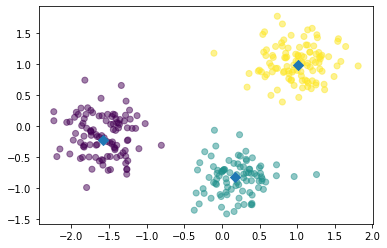

In [ ]:
# Assign the columns of new_points: xs and ys
xs = new_points[:, 0]
ys = new_points[:, 1]

# Make a scatter plot of xs and ys, using labels to define the colors
plt.scatter(xs, ys, c=labels, alpha=0.5)

# Assign the cluster centers: centroids
centroids = model.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y
centroids_x = centroids[:,0]
centroids_y = centroids[:,1]

# Make a scatter plot of centroids_x and centroids_y
plt.scatter(centroids_x, centroids_y, marker='D', s=50)
plt.show()

How can you be sure that 3 clusters is the correct choice? In other words, how can you evaluate the quality of a clustering?

# **Aligning labels and species**



In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

samples = datasets.load_iris()['data']
species = datasets.load_iris()['target']

model = KMeans(n_clusters=3).fit(samples)
labels = model.predict(samples)

df = pd.DataFrame({'labels': labels, 'species': species})
df

,labels,species
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
145,2,2
146,1,2
147,2,2
148,2,2


## **Crosstab of labels and species**

In [ ]:
pd.crosstab(df['labels'], df['species'])

species,0,1,2
labels,,,
0,50,0,0
1,0,48,14
2,0,2,36


If data have actual labels, crosstab can measure the quality of clustering.  But for unsupervised learning usually we do not have labels for target variable.


# ***Inertia measures clustering quality***

* Distance from each sample to centroid of its cluster

* k-means attempts to minimize the inertia when choosing
clusters
* Lower inertia is better, but not too many clusters!
* เลือกจากจุดหักมุม ในรูปกราฟ

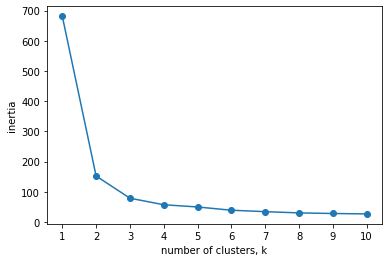

In [ ]:
k = np.arange(1, 11)
inertia = np.empty(10)

for i in range(1, 11):
    model = KMeans(n_clusters=i)
    model.fit(samples)
    inertia[i-1] = model.inertia_

plt.plot(k, inertia, marker='o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(np.arange(1,))
plt.show()

### ***Exercise: How many clusters of grain?***

You learned how to choose a good number of clusters for a dataset using the k-means inertia graph. You are given an array `samples` containing the measurements (such as area, perimeter, length, and several others) of samples of grain. What's a good number of clusters in this case?

For each of the given values of `k`, perform the following steps:

* Create a `KMeans` instance called `model` with `k` clusters.
* Fit the model to the grain data `samples`.
* Append the value of the `inertia_` attribute of `model` to the list `inertias`.


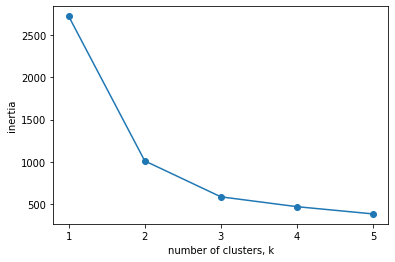

In [ ]:
samples = np.array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ],
       [14.38  , 14.21  ,  0.8951,  5.386 ,  3.312 ,  2.462 ,  4.956 ],
       [14.69  , 14.49  ,  0.8799,  5.563 ,  3.259 ,  3.586 ,  5.219 ],
       [14.11  , 14.1   ,  0.8911,  5.42  ,  3.302 ,  2.7   ,  5.    ],
       [16.63  , 15.46  ,  0.8747,  6.053 ,  3.465 ,  2.04  ,  5.877 ],
       [16.44  , 15.25  ,  0.888 ,  5.884 ,  3.505 ,  1.969 ,  5.533 ],
       [15.26  , 14.85  ,  0.8696,  5.714 ,  3.242 ,  4.543 ,  5.314 ],
       [14.03  , 14.16  ,  0.8796,  5.438 ,  3.201 ,  1.717 ,  5.001 ],
       [13.89  , 14.02  ,  0.888 ,  5.439 ,  3.199 ,  3.986 ,  4.738 ],
       [13.78  , 14.06  ,  0.8759,  5.479 ,  3.156 ,  3.136 ,  4.872 ],
       [13.74  , 14.05  ,  0.8744,  5.482 ,  3.114 ,  2.932 ,  4.825 ],
       [14.59  , 14.28  ,  0.8993,  5.351 ,  3.333 ,  4.185 ,  4.781 ],
       [13.99  , 13.83  ,  0.9183,  5.119 ,  3.383 ,  5.234 ,  4.781 ],
       [15.69  , 14.75  ,  0.9058,  5.527 ,  3.514 ,  1.599 ,  5.046 ],
       [14.7   , 14.21  ,  0.9153,  5.205 ,  3.466 ,  1.767 ,  4.649 ],
       [12.72  , 13.57  ,  0.8686,  5.226 ,  3.049 ,  4.102 ,  4.914 ],
       [14.16  , 14.4   ,  0.8584,  5.658 ,  3.129 ,  3.072 ,  5.176 ],
       [14.11  , 14.26  ,  0.8722,  5.52  ,  3.168 ,  2.688 ,  5.219 ],
       [15.88  , 14.9   ,  0.8988,  5.618 ,  3.507 ,  0.7651,  5.091 ],
       [12.08  , 13.23  ,  0.8664,  5.099 ,  2.936 ,  1.415 ,  4.961 ],
       [15.01  , 14.76  ,  0.8657,  5.789 ,  3.245 ,  1.791 ,  5.001 ],
       [16.19  , 15.16  ,  0.8849,  5.833 ,  3.421 ,  0.903 ,  5.307 ],
       [13.02  , 13.76  ,  0.8641,  5.395 ,  3.026 ,  3.373 ,  4.825 ],
       [12.74  , 13.67  ,  0.8564,  5.395 ,  2.956 ,  2.504 ,  4.869 ],
       [14.11  , 14.18  ,  0.882 ,  5.541 ,  3.221 ,  2.754 ,  5.038 ],
       [13.45  , 14.02  ,  0.8604,  5.516 ,  3.065 ,  3.531 ,  5.097 ],
       [13.16  , 13.82  ,  0.8662,  5.454 ,  2.975 ,  0.8551,  5.056 ],
       [15.49  , 14.94  ,  0.8724,  5.757 ,  3.371 ,  3.412 ,  5.228 ],
       [14.09  , 14.41  ,  0.8529,  5.717 ,  3.186 ,  3.92  ,  5.299 ],
       [13.94  , 14.17  ,  0.8728,  5.585 ,  3.15  ,  2.124 ,  5.012 ],
       [15.05  , 14.68  ,  0.8779,  5.712 ,  3.328 ,  2.129 ,  5.36  ],
       [16.12  , 15.    ,  0.9   ,  5.709 ,  3.485 ,  2.27  ,  5.443 ],
       [16.2   , 15.27  ,  0.8734,  5.826 ,  3.464 ,  2.823 ,  5.527 ],
       [17.08  , 15.38  ,  0.9079,  5.832 ,  3.683 ,  2.956 ,  5.484 ],
       [14.8   , 14.52  ,  0.8823,  5.656 ,  3.288 ,  3.112 ,  5.309 ],
       [14.28  , 14.17  ,  0.8944,  5.397 ,  3.298 ,  6.685 ,  5.001 ],
       [13.54  , 13.85  ,  0.8871,  5.348 ,  3.156 ,  2.587 ,  5.178 ],
       [13.5   , 13.85  ,  0.8852,  5.351 ,  3.158 ,  2.249 ,  5.176 ],
       [13.16  , 13.55  ,  0.9009,  5.138 ,  3.201 ,  2.461 ,  4.783 ],
       [15.5   , 14.86  ,  0.882 ,  5.877 ,  3.396 ,  4.711 ,  5.528 ],
       [15.11  , 14.54  ,  0.8986,  5.579 ,  3.462 ,  3.128 ,  5.18  ],
       [13.8   , 14.04  ,  0.8794,  5.376 ,  3.155 ,  1.56  ,  4.961 ],
       [15.36  , 14.76  ,  0.8861,  5.701 ,  3.393 ,  1.367 ,  5.132 ],
       [14.99  , 14.56  ,  0.8883,  5.57  ,  3.377 ,  2.958 ,  5.175 ],
       [14.79  , 14.52  ,  0.8819,  5.545 ,  3.291 ,  2.704 ,  5.111 ],
       [14.86  , 14.67  ,  0.8676,  5.678 ,  3.258 ,  2.129 ,  5.351 ],
       [14.43  , 14.4   ,  0.8751,  5.585 ,  3.272 ,  3.975 ,  5.144 ],
       [15.78  , 14.91  ,  0.8923,  5.674 ,  3.434 ,  5.593 ,  5.136 ],
       [14.49  , 14.61  ,  0.8538,  5.715 ,  3.113 ,  4.116 ,  5.396 ],
       [14.33  , 14.28  ,  0.8831,  5.504 ,  3.199 ,  3.328 ,  5.224 ],
       [14.52  , 14.6   ,  0.8557,  5.741 ,  3.113 ,  1.481 ,  5.487 ],
       [15.03  , 14.77  ,  0.8658,  5.702 ,  3.212 ,  1.933 ,  5.439 ],
       [14.46  , 14.35  ,  0.8818,  5.388 ,  3.377 ,  2.802 ,  5.044 ],
       [14.92  , 14.43  ,  0.9006,  5.384 ,  3.412 ,  1.142 ,  5.088 ],
       [15.38  , 14.77  ,  0.8857,  5.662 ,  3.419 ,  1.999 ,  5.222 ],
       [12.11  , 13.47  ,  0.8392,  5.159 ,  3.032 ,  1.502 ,  4.519 ],
       [11.42  , 12.86  ,  0.8683,  5.008 ,  2.85  ,  2.7   ,  4.607 ],
       [11.23  , 12.63  ,  0.884 ,  4.902 ,  2.879 ,  2.269 ,  4.703 ],
       [12.36  , 13.19  ,  0.8923,  5.076 ,  3.042 ,  3.22  ,  4.605 ],
       [13.22  , 13.84  ,  0.868 ,  5.395 ,  3.07  ,  4.157 ,  5.088 ],
       [12.78  , 13.57  ,  0.8716,  5.262 ,  3.026 ,  1.176 ,  4.782 ],
       [12.88  , 13.5   ,  0.8879,  5.139 ,  3.119 ,  2.352 ,  4.607 ],
       [14.34  , 14.37  ,  0.8726,  5.63  ,  3.19  ,  1.313 ,  5.15  ],
       [14.01  , 14.29  ,  0.8625,  5.609 ,  3.158 ,  2.217 ,  5.132 ],
       [14.37  , 14.39  ,  0.8726,  5.569 ,  3.153 ,  1.464 ,  5.3   ],
       [12.73  , 13.75  ,  0.8458,  5.412 ,  2.882 ,  3.533 ,  5.067 ],
       [17.63  , 15.98  ,  0.8673,  6.191 ,  3.561 ,  4.076 ,  6.06  ],
       [16.84  , 15.67  ,  0.8623,  5.998 ,  3.484 ,  4.675 ,  5.877 ],
       [17.26  , 15.73  ,  0.8763,  5.978 ,  3.594 ,  4.539 ,  5.791 ],
       [19.11  , 16.26  ,  0.9081,  6.154 ,  3.93  ,  2.936 ,  6.079 ],
       [16.82  , 15.51  ,  0.8786,  6.017 ,  3.486 ,  4.004 ,  5.841 ],
       [16.77  , 15.62  ,  0.8638,  5.927 ,  3.438 ,  4.92  ,  5.795 ],
       [17.32  , 15.91  ,  0.8599,  6.064 ,  3.403 ,  3.824 ,  5.922 ],
       [20.71  , 17.23  ,  0.8763,  6.579 ,  3.814 ,  4.451 ,  6.451 ],
       [18.94  , 16.49  ,  0.875 ,  6.445 ,  3.639 ,  5.064 ,  6.362 ],
       [17.12  , 15.55  ,  0.8892,  5.85  ,  3.566 ,  2.858 ,  5.746 ],
       [16.53  , 15.34  ,  0.8823,  5.875 ,  3.467 ,  5.532 ,  5.88  ],
       [18.72  , 16.19  ,  0.8977,  6.006 ,  3.857 ,  5.324 ,  5.879 ],
       [20.2   , 16.89  ,  0.8894,  6.285 ,  3.864 ,  5.173 ,  6.187 ],
       [19.57  , 16.74  ,  0.8779,  6.384 ,  3.772 ,  1.472 ,  6.273 ],
       [19.51  , 16.71  ,  0.878 ,  6.366 ,  3.801 ,  2.962 ,  6.185 ],
       [18.27  , 16.09  ,  0.887 ,  6.173 ,  3.651 ,  2.443 ,  6.197 ],
       [18.88  , 16.26  ,  0.8969,  6.084 ,  3.764 ,  1.649 ,  6.109 ],
       [18.98  , 16.66  ,  0.859 ,  6.549 ,  3.67  ,  3.691 ,  6.498 ],
       [21.18  , 17.21  ,  0.8989,  6.573 ,  4.033 ,  5.78  ,  6.231 ],
       [20.88  , 17.05  ,  0.9031,  6.45  ,  4.032 ,  5.016 ,  6.321 ],
       [20.1   , 16.99  ,  0.8746,  6.581 ,  3.785 ,  1.955 ,  6.449 ],
       [18.76  , 16.2   ,  0.8984,  6.172 ,  3.796 ,  3.12  ,  6.053 ],
       [18.81  , 16.29  ,  0.8906,  6.272 ,  3.693 ,  3.237 ,  6.053 ],
       [18.59  , 16.05  ,  0.9066,  6.037 ,  3.86  ,  6.001 ,  5.877 ],
       [18.36  , 16.52  ,  0.8452,  6.666 ,  3.485 ,  4.933 ,  6.448 ],
       [16.87  , 15.65  ,  0.8648,  6.139 ,  3.463 ,  3.696 ,  5.967 ],
       [19.31  , 16.59  ,  0.8815,  6.341 ,  3.81  ,  3.477 ,  6.238 ],
       [18.98  , 16.57  ,  0.8687,  6.449 ,  3.552 ,  2.144 ,  6.453 ],
       [18.17  , 16.26  ,  0.8637,  6.271 ,  3.512 ,  2.853 ,  6.273 ],
       [18.72  , 16.34  ,  0.881 ,  6.219 ,  3.684 ,  2.188 ,  6.097 ],
       [16.41  , 15.25  ,  0.8866,  5.718 ,  3.525 ,  4.217 ,  5.618 ],
       [17.99  , 15.86  ,  0.8992,  5.89  ,  3.694 ,  2.068 ,  5.837 ],
       [19.46  , 16.5   ,  0.8985,  6.113 ,  3.892 ,  4.308 ,  6.009 ],
       [19.18  , 16.63  ,  0.8717,  6.369 ,  3.681 ,  3.357 ,  6.229 ],
       [18.95  , 16.42  ,  0.8829,  6.248 ,  3.755 ,  3.368 ,  6.148 ],
       [18.83  , 16.29  ,  0.8917,  6.037 ,  3.786 ,  2.553 ,  5.879 ],
       [18.85  , 16.17  ,  0.9056,  6.152 ,  3.806 ,  2.843 ,  6.2   ],
       [17.63  , 15.86  ,  0.88  ,  6.033 ,  3.573 ,  3.747 ,  5.929 ],
       [19.94  , 16.92  ,  0.8752,  6.675 ,  3.763 ,  3.252 ,  6.55  ],
       [18.55  , 16.22  ,  0.8865,  6.153 ,  3.674 ,  1.738 ,  5.894 ],
       [18.45  , 16.12  ,  0.8921,  6.107 ,  3.769 ,  2.235 ,  5.794 ],
       [19.38  , 16.72  ,  0.8716,  6.303 ,  3.791 ,  3.678 ,  5.965 ],
       [19.13  , 16.31  ,  0.9035,  6.183 ,  3.902 ,  2.109 ,  5.924 ],
       [19.14  , 16.61  ,  0.8722,  6.259 ,  3.737 ,  6.682 ,  6.053 ],
       [20.97  , 17.25  ,  0.8859,  6.563 ,  3.991 ,  4.677 ,  6.316 ],
       [19.06  , 16.45  ,  0.8854,  6.416 ,  3.719 ,  2.248 ,  6.163 ],
       [18.96  , 16.2   ,  0.9077,  6.051 ,  3.897 ,  4.334 ,  5.75  ],
       [19.15  , 16.45  ,  0.889 ,  6.245 ,  3.815 ,  3.084 ,  6.185 ],
       [18.89  , 16.23  ,  0.9008,  6.227 ,  3.769 ,  3.639 ,  5.966 ],
       [20.03  , 16.9   ,  0.8811,  6.493 ,  3.857 ,  3.063 ,  6.32  ],
       [20.24  , 16.91  ,  0.8897,  6.315 ,  3.962 ,  5.901 ,  6.188 ],
       [18.14  , 16.12  ,  0.8772,  6.059 ,  3.563 ,  3.619 ,  6.011 ],
       [16.17  , 15.38  ,  0.8588,  5.762 ,  3.387 ,  4.286 ,  5.703 ],
       [18.43  , 15.97  ,  0.9077,  5.98  ,  3.771 ,  2.984 ,  5.905 ],
       [15.99  , 14.89  ,  0.9064,  5.363 ,  3.582 ,  3.336 ,  5.144 ],
       [18.75  , 16.18  ,  0.8999,  6.111 ,  3.869 ,  4.188 ,  5.992 ],
       [18.65  , 16.41  ,  0.8698,  6.285 ,  3.594 ,  4.391 ,  6.102 ],
       [17.98  , 15.85  ,  0.8993,  5.979 ,  3.687 ,  2.257 ,  5.919 ],
       [20.16  , 17.03  ,  0.8735,  6.513 ,  3.773 ,  1.91  ,  6.185 ],
       [17.55  , 15.66  ,  0.8991,  5.791 ,  3.69  ,  5.366 ,  5.661 ],
       [18.3   , 15.89  ,  0.9108,  5.979 ,  3.755 ,  2.837 ,  5.962 ],
       [18.94  , 16.32  ,  0.8942,  6.144 ,  3.825 ,  2.908 ,  5.949 ],
       [15.38  , 14.9   ,  0.8706,  5.884 ,  3.268 ,  4.462 ,  5.795 ],
       [16.16  , 15.33  ,  0.8644,  5.845 ,  3.395 ,  4.266 ,  5.795 ],
       [15.56  , 14.89  ,  0.8823,  5.776 ,  3.408 ,  4.972 ,  5.847 ],
       [15.38  , 14.66  ,  0.899 ,  5.477 ,  3.465 ,  3.6   ,  5.439 ],
       [17.36  , 15.76  ,  0.8785,  6.145 ,  3.574 ,  3.526 ,  5.971 ],
       [15.57  , 15.15  ,  0.8527,  5.92  ,  3.231 ,  2.64  ,  5.879 ],
       [15.6   , 15.11  ,  0.858 ,  5.832 ,  3.286 ,  2.725 ,  5.752 ],
       [16.23  , 15.18  ,  0.885 ,  5.872 ,  3.472 ,  3.769 ,  5.922 ],
       [13.07  , 13.92  ,  0.848 ,  5.472 ,  2.994 ,  5.304 ,  5.395 ],
       [13.32  , 13.94  ,  0.8613,  5.541 ,  3.073 ,  7.035 ,  5.44  ],
       [13.34  , 13.95  ,  0.862 ,  5.389 ,  3.074 ,  5.995 ,  5.307 ],
       [12.22  , 13.32  ,  0.8652,  5.224 ,  2.967 ,  5.469 ,  5.221 ],
       [11.82  , 13.4   ,  0.8274,  5.314 ,  2.777 ,  4.471 ,  5.178 ],
       [11.21  , 13.13  ,  0.8167,  5.279 ,  2.687 ,  6.169 ,  5.275 ],
       [11.43  , 13.13  ,  0.8335,  5.176 ,  2.719 ,  2.221 ,  5.132 ],
       [12.49  , 13.46  ,  0.8658,  5.267 ,  2.967 ,  4.421 ,  5.002 ],
       [12.7   , 13.71  ,  0.8491,  5.386 ,  2.911 ,  3.26  ,  5.316 ],
       [10.79  , 12.93  ,  0.8107,  5.317 ,  2.648 ,  5.462 ,  5.194 ],
       [11.83  , 13.23  ,  0.8496,  5.263 ,  2.84  ,  5.195 ,  5.307 ],
       [12.01  , 13.52  ,  0.8249,  5.405 ,  2.776 ,  6.992 ,  5.27  ],
       [12.26  , 13.6   ,  0.8333,  5.408 ,  2.833 ,  4.756 ,  5.36  ],
       [11.18  , 13.04  ,  0.8266,  5.22  ,  2.693 ,  3.332 ,  5.001 ],
       [11.36  , 13.05  ,  0.8382,  5.175 ,  2.755 ,  4.048 ,  5.263 ],
       [11.19  , 13.05  ,  0.8253,  5.25  ,  2.675 ,  5.813 ,  5.219 ],
       [11.34  , 12.87  ,  0.8596,  5.053 ,  2.849 ,  3.347 ,  5.003 ],
       [12.13  , 13.73  ,  0.8081,  5.394 ,  2.745 ,  4.825 ,  5.22  ],
       [11.75  , 13.52  ,  0.8082,  5.444 ,  2.678 ,  4.378 ,  5.31  ],
       [11.49  , 13.22  ,  0.8263,  5.304 ,  2.695 ,  5.388 ,  5.31  ],
       [12.54  , 13.67  ,  0.8425,  5.451 ,  2.879 ,  3.082 ,  5.491 ],
       [12.02  , 13.33  ,  0.8503,  5.35  ,  2.81  ,  4.271 ,  5.308 ],
       [12.05  , 13.41  ,  0.8416,  5.267 ,  2.847 ,  4.988 ,  5.046 ],
       [12.55  , 13.57  ,  0.8558,  5.333 ,  2.968 ,  4.419 ,  5.176 ],
       [11.14  , 12.79  ,  0.8558,  5.011 ,  2.794 ,  6.388 ,  5.049 ],
       [12.1   , 13.15  ,  0.8793,  5.105 ,  2.941 ,  2.201 ,  5.056 ],
       [12.44  , 13.59  ,  0.8462,  5.319 ,  2.897 ,  4.924 ,  5.27  ],
       [12.15  , 13.45  ,  0.8443,  5.417 ,  2.837 ,  3.638 ,  5.338 ],
       [11.35  , 13.12  ,  0.8291,  5.176 ,  2.668 ,  4.337 ,  5.132 ],
       [11.24  , 13.    ,  0.8359,  5.09  ,  2.715 ,  3.521 ,  5.088 ],
       [11.02  , 13.    ,  0.8189,  5.325 ,  2.701 ,  6.735 ,  5.163 ],
       [11.55  , 13.1   ,  0.8455,  5.167 ,  2.845 ,  6.715 ,  4.956 ],
       [11.27  , 12.97  ,  0.8419,  5.088 ,  2.763 ,  4.309 ,  5.    ],
       [11.4   , 13.08  ,  0.8375,  5.136 ,  2.763 ,  5.588 ,  5.089 ],
       [10.83  , 12.96  ,  0.8099,  5.278 ,  2.641 ,  5.182 ,  5.185 ],
       [10.8   , 12.57  ,  0.859 ,  4.981 ,  2.821 ,  4.773 ,  5.063 ],
       [11.26  , 13.01  ,  0.8355,  5.186 ,  2.71  ,  5.335 ,  5.092 ],
       [10.74  , 12.73  ,  0.8329,  5.145 ,  2.642 ,  4.702 ,  4.963 ],
       [11.48  , 13.05  ,  0.8473,  5.18  ,  2.758 ,  5.876 ,  5.002 ],
       [12.21  , 13.47  ,  0.8453,  5.357 ,  2.893 ,  1.661 ,  5.178 ],
       [11.41  , 12.95  ,  0.856 ,  5.09  ,  2.775 ,  4.957 ,  4.825 ],
       [12.46  , 13.41  ,  0.8706,  5.236 ,  3.017 ,  4.987 ,  5.147 ],
       [12.19  , 13.36  ,  0.8579,  5.24  ,  2.909 ,  4.857 ,  5.158 ],
       [11.65  , 13.07  ,  0.8575,  5.108 ,  2.85  ,  5.209 ,  5.135 ],
       [12.89  , 13.77  ,  0.8541,  5.495 ,  3.026 ,  6.185 ,  5.316 ],
       [11.56  , 13.31  ,  0.8198,  5.363 ,  2.683 ,  4.062 ,  5.182 ],
       [11.81  , 13.45  ,  0.8198,  5.413 ,  2.716 ,  4.898 ,  5.352 ],
       [10.91  , 12.8   ,  0.8372,  5.088 ,  2.675 ,  4.179 ,  4.956 ],
       [11.23  , 12.82  ,  0.8594,  5.089 ,  2.821 ,  7.524 ,  4.957 ],
       [10.59  , 12.41  ,  0.8648,  4.899 ,  2.787 ,  4.975 ,  4.794 ],
       [10.93  , 12.8   ,  0.839 ,  5.046 ,  2.717 ,  5.398 ,  5.045 ],
       [11.27  , 12.86  ,  0.8563,  5.091 ,  2.804 ,  3.985 ,  5.001 ],
       [11.87  , 13.02  ,  0.8795,  5.132 ,  2.953 ,  3.597 ,  5.132 ],
       [10.82  , 12.83  ,  0.8256,  5.18  ,  2.63  ,  4.853 ,  5.089 ],
       [12.11  , 13.27  ,  0.8639,  5.236 ,  2.975 ,  4.132 ,  5.012 ],
       [12.8   , 13.47  ,  0.886 ,  5.16  ,  3.126 ,  4.873 ,  4.914 ],
       [12.79  , 13.53  ,  0.8786,  5.224 ,  3.054 ,  5.483 ,  4.958 ],
       [13.37  , 13.78  ,  0.8849,  5.32  ,  3.128 ,  4.67  ,  5.091 ],
       [12.62  , 13.67  ,  0.8481,  5.41  ,  2.911 ,  3.306 ,  5.231 ],
       [12.76  , 13.38  ,  0.8964,  5.073 ,  3.155 ,  2.828 ,  4.83  ],
       [12.38  , 13.44  ,  0.8609,  5.219 ,  2.989 ,  5.472 ,  5.045 ],
       [12.67  , 13.32  ,  0.8977,  4.984 ,  3.135 ,  2.3   ,  4.745 ],
       [11.18  , 12.72  ,  0.868 ,  5.009 ,  2.81  ,  4.051 ,  4.828 ],
       [12.7   , 13.41  ,  0.8874,  5.183 ,  3.091 ,  8.456 ,  5.    ],
       [12.37  , 13.47  ,  0.8567,  5.204 ,  2.96  ,  3.919 ,  5.001 ],
       [12.19  , 13.2   ,  0.8783,  5.137 ,  2.981 ,  3.631 ,  4.87  ],
       [11.23  , 12.88  ,  0.8511,  5.14  ,  2.795 ,  4.325 ,  5.003 ],
       [13.2   , 13.66  ,  0.8883,  5.236 ,  3.232 ,  8.315 ,  5.056 ],
       [11.84  , 13.21  ,  0.8521,  5.175 ,  2.836 ,  3.598 ,  5.044 ],
       [12.3   , 13.34  ,  0.8684,  5.243 ,  2.974 ,  5.637 ,  5.063 ]])

ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters=k)

    # Fit model to samples
    model.fit(samples)

    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

The inertia decreases very slowly from 3 clusters to 4, so it looks like 3 clusters would be a good choice for this data.

### ***Evaluating the grain clustering***

In the previous exercise, you observed from the inertia plot that 3 is a good number of clusters for the grain data. In fact, the grain samples come from a mix of 3 different grain varieties: "Kama", "Rosa" and "Canadian". In this exercise, cluster the grain samples into three clusters, and compare the clusters to the grain varieties using a cross-tabulation.

You have the array `samples` of grain samples, and a list varieties giving the grain variety for each sample.

* Create a `KMeans` model called `model` with `3` clusters.
* Use the `.fit_predict()` method of `model` to fit it to `samples` and derive the cluster labels. Using `.fit_predict()` is the same as using `.fit()` followed by `.predict()`.
* Create a DataFrame `df` with two columns named `'labels'` and `'varieties'`, using `labels` and `varieties`, respectively, for the column values.
* Use the `pd.crosstab()` function on `df['labels']` and `df['varieties']` to count the number of times each grain variety coincides with each cluster label. Assign the result to `ct`.

In [ ]:
varieties = ['Kama wheat',  'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat','Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat','Kama wheat','Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat','Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat','Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat','Kama wheat', 'Kama wheat', 'Kama wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat','Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat','Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat','Canadian wheat','Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat']

# Create a KMeans model with 3 clusters: model
model = KMeans(n_clusters=3)

# Use fit_predict to fit model and obtain cluster labels: labels
labels = model.fit_predict(samples)

# Create a DataFrame with labels and varieties as columns: df
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
print(ct)


varieties  Canadian wheat  Kama wheat  Rosa wheat
labels                                           
0                       0           1          60
1                       2          60          10
2                      68           9           0


 The cross-tabulation shows that the 3 varieties of grain separate really well into 3 clusters. But depending on the type of data you are working with, the clustering may not always be this good. Is there anything you can do in such situations to improve your clustering?

In [ ]:
samples = pd.read_csv('wine.csv').drop(columns=['class_name', 'class_label'])
varieties = pd.read_csv('wine.csv')['class_name']

model = KMeans(n_clusters=3)
labels = model.fit_predict(samples)
df = pd.DataFrame({'labels': labels, 'varieties': varieties})
pd.crosstab(df['labels'], df['varieties'])

varieties,Barbera,Barolo,Grignolino
labels,,,
0,19,0,50
1,0,46,1
2,29,13,20


ตาราง crosstab แสดงให้เห็นว่า KMeans แบ่งได้ไม่ค่อยดีแล้ว เนื่องมาจากมีค่าความแปรปรวนที่แตกต่างกันในแต่ละตัวแปร จึงต้องใช้

# ***StandardScaler***

## **Similar methods**

* Use **`fit()`** / **`transform()`** with **`StandardScaler`**
* Use **`fit()`** / **`predict()`** with **`KMeans`**



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
scaler.fit(samples)
samples_scaled = scaler.transform(samples)

model = KMeans(n_clusters=3)
labels = model.fit_predict(samples_scaled)
df = pd.DataFrame({'labels': labels, 'varieties': varieties})
pd.crosstab(df['labels'], df['varieties'])

varieties,Barbera,Barolo,Grignolino
labels,,,
0,48,0,3
1,0,59,2
2,0,0,66


จะเห็นว่า KMeans จัดกลุ่มได้ดีขึ้น แต่เราสามารถทำใน pipeline ได้

# ***Pipelines combine multiple steps***

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

samples = pd.read_csv('wine.csv').drop(columns=['class_name', 'class_label'])
varieties = pd.read_csv('wine.csv')['class_name']

scaler = StandardScaler()
kmeans = KMeans(n_clusters=3)
pipeline = make_pipeline(scaler, kmeans)
pipeline.fit(samples)
labels = pipeline.predict(samples)

df = pd.DataFrame({'labels': labels, 'varieties': varieties})
pd.crosstab(df['labels'], df['varieties'])

varieties,Barbera,Barolo,Grignolino
labels,,,
0,0,59,3
1,48,0,3
2,0,0,65


### ***Exercise: Scaling fish data for clustering***

You are given an array `samples` giving measurements of fish. Each row represents an individual fish. The measurements, such as weight in grams, length in centimeters, and the percentage ratio of height to length, have very different scales. In order to cluster this data effectively, you'll need to standardize these features first. In this exercise, you'll build a pipeline to standardize and cluster the data.

* Import:
  * `make_pipeline` from `sklearn.pipeline`.
  * `StandardScaler` from `sklearn.preprocessing`.
  * `KMeans` from `sklearn.cluster`.

* Create an instance of `StandardScaler` called `scaler`.
* Create an instance of `KMeans` with `4` clusters called `kmeans`.
* Create a pipeline called `pipeline` that chains `scaler` and `kmeans`. To do this, you just need to pass them in as arguments to `make_pipeline()`.

In [ ]:
# Perform the necessary imports
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

samples = pd.read_csv('fish.csv', header=None).drop(columns=0).values
species = pd.read_csv('fish.csv', header=None)[0].to_list()

# Create scaler: scaler
scaler = StandardScaler()

# Create KMeans instance: kmeans
kmeans = KMeans(n_clusters=4)

# Create pipeline: pipeline
pipeline = make_pipeline(scaler, kmeans)


### ***Exercise: Clustering the fish data***

You'll now use your standardization and clustering pipeline from the previous exercise to cluster the fish by their measurements, and then create a cross-tabulation to compare the cluster labels with the fish species.

As before, samples is the 2D array of fish measurements. Your pipeline is available as `pipeline`, and the species of every fish sample is given by the list `species`.

* Fit the `pipeline` to the fish measurements `samples`.
* Obtain the cluster labels for samples by using the `.predict()` method of `pipeline`.
* Using `pd.DataFrame()`, create a DataFrame `df` with two columns named `'labels'` and `'species'`, using `labels` and `species`, respectively, for the column values.
* Using `pd.crosstab()`, create a cross-tabulation `ct` of `df['labels']` and `df['species']`.

In [ ]:
# Fit the pipeline to samples
pipeline.fit(samples)

# Calculate the cluster labels: labels
labels = pipeline.predict(samples)

# Create a DataFrame with labels and species as columns: df
df = pd.DataFrame({'labels': labels, 'species': species})

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['species'])

# Display ct
display(ct)


species,Bream,Pike,Roach,Smelt
labels,,,,
0,0,17,0,0
1,33,0,1,0
2,1,0,19,1
3,0,0,0,13


### ***Exercise: Clustering stocks using KMeans***

In this exercise, you'll cluster companies using their daily stock price movements (i.e. the dollar difference between the closing and opening prices for each trading day). You are given a NumPy array` movements` of daily price movements from 2010 to 2015 (obtained from Yahoo! Finance), where each row corresponds to a company, and each column corresponds to a trading day.

Some stocks are more expensive than others. To account for this, include a `Normalizer` at the beginning of your `pipeline`. The `Normalizer` will separately transform each company's stock price to a relative scale before the clustering begins.

Note that `Normalizer()` is different to `StandardScaler()`, which you used in the previous exercise. While `StandardScaler()` standardizes features (such as the features of the fish data from the previous exercise) by removing the mean and scaling to unit variance, `Normalizer()` rescales each sample - here, each company's stock price - independently of the other.

`KMeans` and `make_pipeline` have already been imported for you.

* Import `Normalizer` from `sklearn.preprocessing`.
* Create an instance of `Normalizer` called `normalizer`.
* Create an instance of `KMeans` called `kmeans` with `10` clusters.
* Using `make_pipeline()`, create a pipeline called `pipeline` that chains `normalizer` and `kmeans`.
* Fit the `pipeline` to the movements `array`.

In [ ]:
from sklearn.preprocessing import Normalizer

movements = pd.read_csv('company-stock-movements-2010-2015-incl.csv').drop(columns='Unnamed: 0').values
companies = pd.read_csv('company-stock-movements-2010-2015-incl.csv')['Unnamed: 0'].values

# Create a normalizer: normalizer
normalizer = Normalizer()

# Create a KMeans model with 10 clusters: kmeans
kmeans = KMeans(n_clusters=10)

# Make a pipeline chaining normalizer and kmeans: pipeline
pipeline = make_pipeline(normalizer, kmeans)

# Fit pipeline to the daily price movements
pipeline.fit(movements)

Pipeline(steps=[('normalizer', Normalizer()),
                ('kmeans', KMeans(n_clusters=10))])

### ***Exercise: Which stocks move together?***

In the previous exercise, you clustered companies by their daily stock price movements. So ***which company have stock prices that tend to change in the same way?*** You'll now inspect the cluster labels from your clustering to find out.

Your solution to the previous exercise has already been run. Recall that you constructed a Pipeline `pipeline` containing a KMeans model and fit it to the NumPy array `movements` of daily stock movements. In addition, a list `companies` of the company names is available.

* Use the `.predict()` method of the `pipeline` to predict the `labels` for `movements`.
* Align the cluster `labels` with the list of company names `companies` by creating a DataFrame `df` with `labels` and `companies` as columns.

* Use the `.sort_values()` method of df to sort the DataFrame by the `'labels'` column, and print the result.



In [ ]:
# Predict the cluster labels: labels
labels = pipeline.predict(movements)

# Create a DataFrame aligning labels and companies: df
df = pd.DataFrame({'labels': labels, 'companies': companies})

# Display df sorted by cluster label
display(df.sort_values(by='labels'))

,labels,companies
44,0,Schlumberger
53,0,Valero Energy
16,0,General Electrics
58,0,Xerox
13,0,DuPont de Nemours
12,0,Chevron
32,0,3M
8,0,Caterpillar
10,0,ConocoPhillips
35,0,Navistar


# **Visualizing Hierachy**


## **Hierachical Clustering**

* Clusters are contained in one another


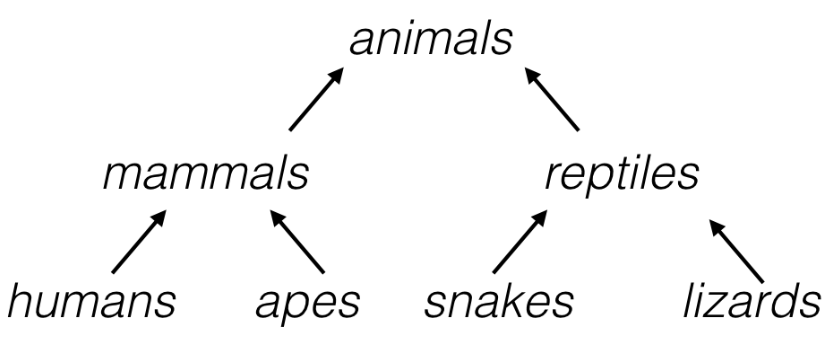

Samples of data

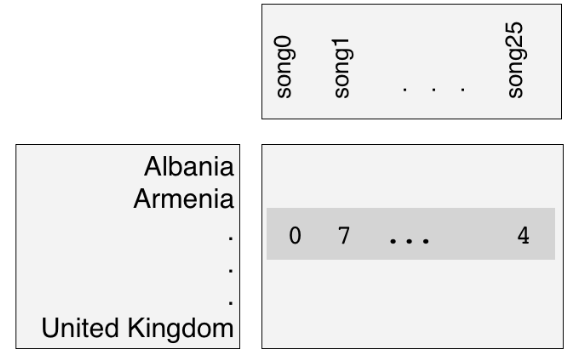

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

mergings = linkage(samples, method='complete')

dendrogram(mergings,
           labels=country_names, # list of country names
           leaf_rotation=90,
           leaf_font_size=6)
plt.show()

### ***Exercise: Hierarchical clustering of the grain data***

Use the **`linkage()`** function to obtain a hierarchical clustering of the grain samples, and use **`dendrogram()`** to visualize the result. A sample of the grain measurements is provided in the array `samples`, while the variety of each grain sample is given by the list `varieties`.

* Perform hierarchical clustering on `samples` using the `linkage()` function with the `method='complete'` keyword argument. Assign the result to `mergings`.

* Plot a dendrogram using the `dendrogram()` function on `mergings`. Specify the keyword arguments `labels=varieties`, `leaf_rotation=90`, and `leaf_font_size=6`.

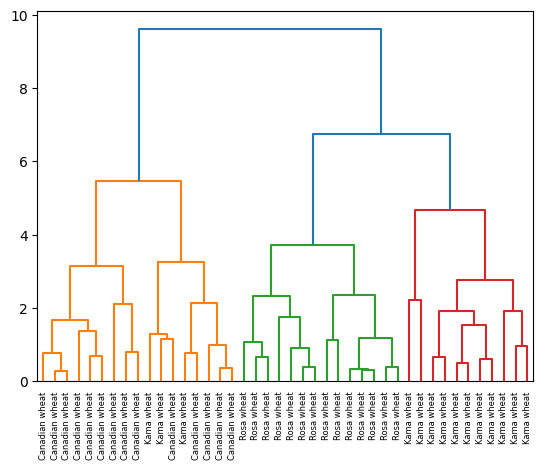

In [ ]:
samples = np.array([[14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],       [14.69  , 14.49  ,  0.8799,  5.563 ,  3.259 ,  3.586 ,  5.219 ], [14.03  , 14.16  ,  0.8796,  5.438 ,  3.201 ,  1.717 ,  5.001 ], [13.99  , 13.83  ,  0.9183,  5.119 ,  3.383 ,  5.234 ,  4.781 ], [14.11  , 14.26  ,  0.8722,  5.52  ,  3.168 ,  2.688 ,  5.219 ], [13.02  , 13.76  ,  0.8641,  5.395 ,  3.026 ,  3.373 ,  4.825 ], [15.49  , 14.94  ,  0.8724,  5.757 ,  3.371 ,  3.412 ,  5.228 ], [16.2   , 15.27  ,  0.8734,  5.826 ,  3.464 ,  2.823 ,  5.527 ], [13.5   , 13.85  ,  0.8852,  5.351 ,  3.158 ,  2.249 ,  5.176 ], [15.36  , 14.76  ,  0.8861,  5.701 ,  3.393 ,  1.367 ,  5.132 ], [15.78  , 14.91  ,  0.8923,  5.674 ,  3.434 ,  5.593 ,  5.136 ], [14.46  , 14.35  ,  0.8818,  5.388 ,  3.377 ,  2.802 ,  5.044 ], [11.23  , 12.63  ,  0.884 ,  4.902 ,  2.879 ,  2.269 ,  4.703 ], [14.34  , 14.37  ,  0.8726,  5.63  ,  3.19  ,  1.313 ,  5.15  ], [16.84  , 15.67  ,  0.8623,  5.998 ,  3.484 ,  4.675 ,  5.877 ], [17.32  , 15.91  ,  0.8599,  6.064 ,  3.403 ,  3.824 ,  5.922 ], [18.72  , 16.19  ,  0.8977,  6.006 ,  3.857 ,  5.324 ,  5.879 ], [18.88  , 16.26  ,  0.8969,  6.084 ,  3.764 ,  1.649 ,  6.109 ], [18.76  , 16.2   ,  0.8984,  6.172 ,  3.796 ,  3.12  ,  6.053 ], [19.31  , 16.59  ,  0.8815,  6.341 ,  3.81  ,  3.477 ,  6.238 ], [17.99  , 15.86  ,  0.8992,  5.89  ,  3.694 ,  2.068 ,  5.837 ],     [18.85  , 16.17  ,  0.9056,  6.152 ,  3.806 ,  2.843 ,  6.2   ],       [19.38  , 16.72  ,  0.8716,  6.303 ,  3.791 ,  3.678 ,  5.965 ],       [18.96  , 16.2   ,  0.9077,  6.051 ,  3.897 ,  4.334 ,  5.75  ],       [18.14  , 16.12  ,  0.8772,  6.059 ,  3.563 ,  3.619 ,  6.011 ],       [18.65  , 16.41  ,  0.8698,  6.285 ,  3.594 ,  4.391 ,  6.102 ],       [18.94  , 16.32  ,  0.8942,  6.144 ,  3.825 ,  2.908 ,  5.949 ],       [17.36  , 15.76  ,  0.8785,  6.145 ,  3.574 ,  3.526 ,  5.971 ],       [13.32  , 13.94  ,  0.8613,  5.541 ,  3.073 ,  7.035 ,  5.44  ],       [11.43  , 13.13  ,  0.8335,  5.176 ,  2.719 ,  2.221 ,  5.132 ],       [12.01  , 13.52  ,  0.8249,  5.405 ,  2.776 ,  6.992 ,  5.27  ],       [11.34  , 12.87  ,  0.8596,  5.053 ,  2.849 ,  3.347 ,  5.003 ],       [12.02  , 13.33  ,  0.8503,  5.35  ,  2.81  ,  4.271 ,  5.308 ],       [12.44  , 13.59  ,  0.8462,  5.319 ,  2.897 ,  4.924 ,  5.27  ],       [11.55  , 13.1   ,  0.8455,  5.167 ,  2.845 ,  6.715 ,  4.956 ],       [11.26  , 13.01  ,  0.8355,  5.186 ,  2.71  ,  5.335 ,  5.092 ],       [12.46  , 13.41  ,  0.8706,  5.236 ,  3.017 ,  4.987 ,  5.147 ],       [11.81  , 13.45  ,  0.8198,  5.413 ,  2.716 ,  4.898 ,  5.352 ],       [11.27  , 12.86  ,  0.8563,  5.091 ,  2.804 ,  3.985 ,  5.001 ],       [12.79  , 13.53  ,  0.8786,  5.224 ,  3.054 ,  5.483 ,  4.958 ],       [12.67  , 13.32  ,  0.8977,  4.984 ,  3.135 ,  2.3   ,  4.745 ],       [11.23  , 12.88  ,  0.8511,  5.14  ,  2.795 ,  4.325 ,  5.003 ]])
varieties = ['Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Kama wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat','Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Rosa wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat', 'Canadian wheat']

# Perform the necessary imports
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Calculate the linkage: mergings
mergings = linkage(samples, method='complete')

# Plot the dendrogram, using varieties as labels
dendrogram(mergings, labels=varieties, leaf_rotation=90, leaf_font_size=6)
plt.show()

Dendrograms are a great way to illustrate the arrangement of the clusters produced by hierarchical clustering.

### ***Exercise: Hierarchies of stocks***

Previously, you used k-means clustering to cluster companies according to their stock price movements. Now, you'll perform hierarchical clustering of the companies. You are given a NumPy array of price movements `movements`, where the rows correspond to companies, and a list of the company names `companies`. SciPy hierarchical clustering doesn't fit into a sklearn pipeline, so you'll need to use the `normalize()` function from `sklearn.preprocessing` instead of `Normalizer`.

* Import `normalize` from `sklearn.preprocessing`.
* Rescale the price movements for each stock by using the `normalize()` function on `movements`.
* Apply the `linkage()` function to `normalized_movements`, using `'complete'` linkage, to calculate the hierarchical clustering. Assign the result to `mergings`.
* Plot a dendrogram of the hierarchical clustering, using the list `companies` of company names as the `labels`. In addition, specify the `leaf_rotation=90`, and `leaf_font_size=6` keyword arguments as you did in the previous exercise.

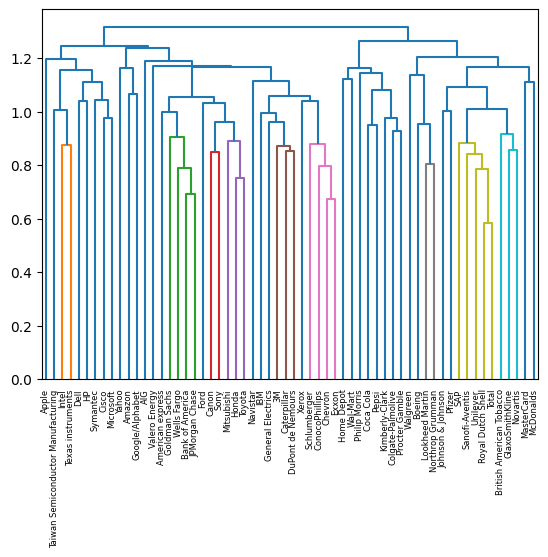

In [ ]:
movements = pd.read_csv('company-stock-movements-2010-2015-incl.csv').drop(columns='Unnamed: 0').values
companies = pd.read_csv('company-stock-movements-2010-2015-incl.csv')['Unnamed: 0'].values

# Import normalize
from sklearn.preprocessing import normalize

# Normalize the movements: normalized_movements
normalized_movements = normalize(movements)

# Calculate the linkage: mergings
mergings = linkage(normalized_movements, method='complete')

# Plot the dendrogram
dendrogram(mergings, labels=companies, leaf_rotation=90, leaf_font_size=6)
plt.show()


# **Cluster labels in Hierarchical Clustering**

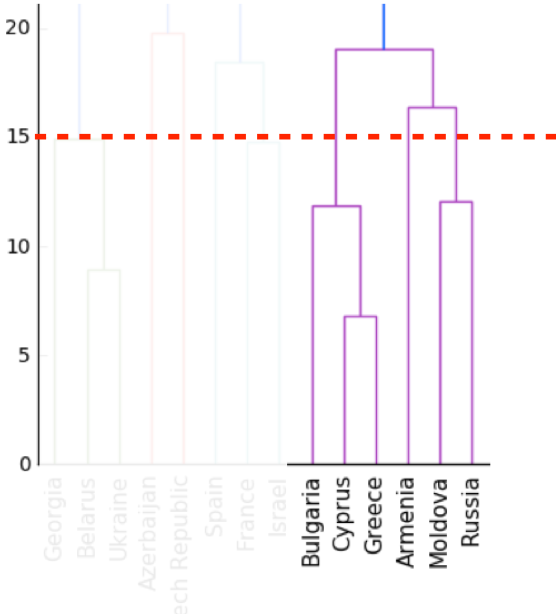

* Height on dendrogram specifies maximum distance between merging clusters

  1. Bulgaria/ Cyprus/ Greece
  2. Russia/ Moldova
  3. Armenia

* Cluster with Cyprus and Greece has distance $\approx$ 6

* Don't merge cluster further apart than 15

## **Distance between clusters**

* Defined by keyword argument in linkage: `method`.
* **`method='complete'`** means distance between clusters is maximum distance between samples
* Different linkage method $=$ different hierarchichal clusters

## **Extracting cluster labels**

* Use the **`fcluster()`** function

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

mergings = linkage(samples, method='complete')
labels = fcluster(mergings, 15, criterion='distance')
pairs = pd.DataFrame(data={'labels': labels, 'countries': country_names}).sort_values(by='labels')

From this dendrogram, the height we should use in **`fcluster`** should correspond to the height in dendrogram.

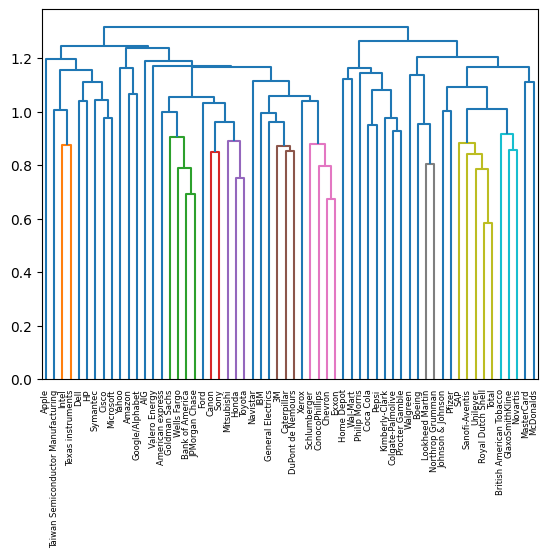

If the height is higher than that in dendrogram, ....

In [ ]:
from sklearn.preprocessing import normalize

movements = pd.read_csv('company-stock-movements-2010-2015-incl.csv').drop(columns='Unnamed: 0').values
companies = pd.read_csv('company-stock-movements-2010-2015-incl.csv')['Unnamed: 0'].values
normalized_movements = normalize(movements)
mergings = linkage(normalized_movements, method='complete')
labels = fcluster(mergings, 3, criterion='distance')


display(pd.DataFrame(data={'labels': labels, 'companies': companies})
      .sort_values(by='labels'))
display(pd.read_csv('company-stock-movements-2010-2015-incl.csv')['Unnamed: 0'])


,labels,companies
0,1,Apple
1,1,AIG
2,1,Amazon
3,1,American express
4,1,Boeing
5,1,Bank of America
6,1,British American Tobacco
7,1,Canon
8,1,Caterpillar
9,1,Colgate-Palmolive


,Unnamed: 0
0,Apple
1,AIG
2,Amazon
3,American express
4,Boeing
5,Bank of America
6,British American Tobacco
7,Canon
8,Caterpillar
9,Colgate-Palmolive


Then the order of companies are similar to the data.  If we specify height = 0.5, we have different ordering.

In [ ]:
labels = fcluster(mergings, 0.5, criterion='distance')

display(pd.DataFrame(data={'labels': labels, 'companies': companies})
      .sort_values(by='labels'))

,labels,companies
24,1,Intel
51,2,Texas instruments
50,3,Taiwan Semiconductor Manufacturing
14,4,Dell
22,5,HP
11,6,Cisco
33,7,Microsoft
47,8,Symantec
0,9,Apple
2,10,Amazon


In [ ]:
labels = fcluster(mergings, 1.25, criterion='distance')

display(pd.DataFrame(data={'labels': labels, 'companies': companies})
      .sort_values(by='labels'))

,labels,companies
0,1,Apple
1,1,AIG
2,1,Amazon
3,1,American express
5,1,Bank of America
7,1,Canon
10,1,ConocoPhillips
8,1,Caterpillar
14,1,Dell
13,1,DuPont de Nemours




### ***Exercise: Different linkage, different hierarchical clustering!***

Perform a hierarchical clustering of the voting countries with `'single'` linkage.  Different linkage, different hierarchical clustering!

You are given an array `samples`. Each row corresponds to a voting country, and each column corresponds to a performance that was voted for. The list `country_names` gives the name of each voting country. This dataset was obtained from Eurovision.

* Perform hierarchical clustering on samples using the `linkage()` function with the `method='single'` keyword argument. Assign the result to `mergings`.

* Plot a dendrogram of the hierarchical clustering, using the list `country_names` as the `labels`. In addition, specify the `leaf_rotation=90`, and `leaf_font_size=6` keyword arguments.

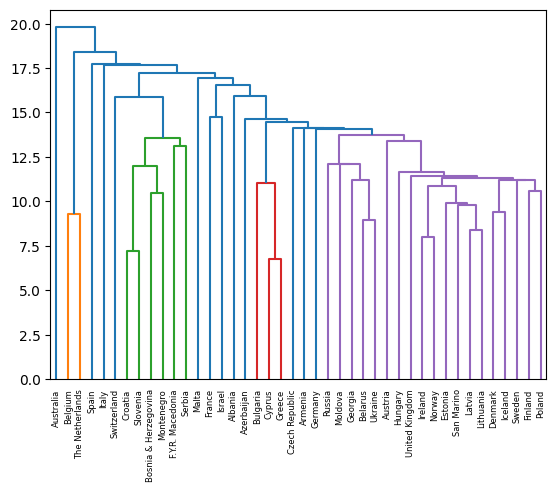

In [ ]:
samples = np.array([[ 2., 12.,  0.,  0.,  0.,  8.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,         0., 10.,  0.,  4.,  0.,  5.,  7.,  0.,  0.,  3.,  0.,  6.,  0.],       [12.,  0.,  4.,  0.,  0.,  0.,  0.,  6.,  0.,  7.,  8.,  0.,  3.,         0.,  0.,  0.,  0.,  5.,  1., 12.,  0.,  0.,  2.,  0., 10.,  0.],       [ 0., 12.,  3.,  0., 12., 10.,  0.,  0.,  0.,  7.,  0.,  0.,  0.,         0.,  0.,  0.,  1.,  6.,  0.,  5.,  0.,  2.,  0.,  0.,  8.,  4.],       [ 0.,  3., 12.,  0.,  0.,  5.,  0.,  0.,  0.,  1.,  0.,  2.,  0.,         0.,  0.,  0.,  0.,  0., 12.,  8.,  4.,  0.,  7.,  6., 10.,  0.],       [ 0.,  2.,  0., 12.,  0.,  8.,  0.,  0.,  0.,  4.,  1.,  0.,  7.,         6.,  0.,  0.,  0.,  5.,  3., 12.,  0.,  0.,  0.,  0., 10.,  0.],       [ 7.,  1.,  0.,  8.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,         0.,  0.,  5.,  0.,  0.,  6., 12.,  0.,  0.,  2.,  0., 10.,  0.],       [ 7.,  4.,  3.,  0., 12.,  5.,  0.,  0.,  0.,  8.,  0.,  0.,  0.,         0.,  0.,  0.,  0.,  0., 12.,  6.,  0.,  0.,  1., 10.,  2.,  0.],       [ 0.,  3.,  5.,  8.,  0.,  2., 10.,  0.,  0.,  4.,  0.,  0.,  1.,       0.,  0.,  0.,  0.,  0.,  0.,  6., 12.,  0.,  0.,  0.,  7.,  0.],       [ 8.,  5.,  4.,  1.,  0., 12.,  0.,  7.,  0.,  0.,  0.,  0.,  0.,         2.,  0.,  0.,  0.,  0.,  6., 12.,  0.,  0.,  3.,  0., 10.,  0.],       [ 0.,  5.,  6.,  0.,  0.,  1., 12.,  0.,  0.,  2.,  0.,  0.,  3.,         0.,  0.,  0.,  0.,  0.,  4.,  8., 12.,  0.,  7.,  0., 10.,  0.],       [ 8.,  5.,  0.,  0.,  0., 12.,  0., 12.,  0.,  6.,  0.,  0.,  4.,         0.,  0.,  0.,  3.,  0.,  2., 10.,  0.,  0.,  1.,  0.,  7.,  0.],       [ 8.,  1.,  4.,  6.,  0.,  5.,  0.,  0., 12.,  0.,  0.,  0.,  3.,         0.,  0.,  0.,  0.,  0.,  7., 10.,  0.,  0.,  2.,  0., 12.,  0.],       [ 0., 10.,  1.,  0.,  8.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,         0.,  0.,  0.,  6.,  0.,  5.,  4.,  0.,  0., 12.,  7.,  3.,  0.],       [ 0.,  4.,  6.,  0.,  0.,  0.,  0.,  3.,  0.,  2.,  0.,  0.,  0.,         0.,  0.,  7.,  5.,  0.,  1., 12.,  0.,  0., 10.,  0.,  8.,  0.],       [ 7.,  3.,  0.,  0.,  4., 10.,  5.,  0.,  0.,  0.,  0.,  0.,  0.,         0.,  1.,  0.,  0.,  0.,  2.,  8., 12.,  0.,  0.,  0.,  6.,  0.],       [ 0.,  7.,  6.,  0.,  0.,  4.,  0.,  1.,  0.,  3.,  0.,  0.,  0.,         0.,  0.,  2.,  0.,  0.,  5.,  8.,  0.,  0., 10.,  0., 12.,  0.],       [12.,  0.,  8.,  0.,  4.,  5.,  0.,  0.,  0., 12.,  0.,  0.,  0.,         3.,  0.,  0.,  0.,  0.,  7.,  6.,  0.,  1.,  2.,  0., 10.,  0.],       [12.,  1.,  0.,  7.,  0.,  3.,  0.,  0.,  0.,  0., 12.,  0.,  2.,         0.,  0.,  6.,  5.,  0.,  4.,  8.,  0.,  0.,  0.,  0., 10.,  0.],       [ 2.,  5.,  7.,  0.,  0.,  4.,  0.,  0.,  0.,  0.,  0., 12.,  0.,         0.,  1.,  0.,  0.,  0., 10., 12.,  0.,  0.,  8.,  3.,  6.,  0.],       [ 8.,  5.,  1.,  0.,  0.,  7.,  0., 12.,  0.,  4.,  0.,  0.,  2.,         0.,  0.,  0.,  0.,  0.,  3., 10.,  0.,  0.,  0.,  0.,  6.,  0.],       [ 0.,  3.,  6.,  0.,  0.,  4.,  0.,  5.,  0.,  1.,  0.,  0., 12.,         0.,  0.,  0.,  0.,  0.,  8., 10.,  0.,  0.,  7.,  2., 12.,  0.],       [ 0.,  8.,  2.,  1.,  3.,  0.,  0.,  0.,  0.,  5.,  0.,  0.,  0.,         0.,  0.,  0.,  4.,  0., 10.,  7.,  0.,  0., 12.,  6.,  0.,  0.],       [ 0.,  6.,  1.,  0.,  0.,  5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,         0.,  0.,  7., 12.,  0., 10.,  8.,  0.,  0.,  2.,  0.,  4.,  3.],       [ 6.,  5.,  3.,  2.,  1.,  7.,  0.,  0.,  0., 12.,  0.,  0.,  0.,        12.,  0.,  0.,  0.,  0.,  4., 10.,  0.,  0.,  0.,  0.,  8.,  0.],       [ 1.,  0.,  0.,  0.,  0.,  7.,  0.,  6.,  0.,  5.,  3.,  0.,  0.,         0., 12.,  0.,  2.,  0., 10.,  8.,  4.,  0.,  0.,  0., 12.,  0.],       [ 0.,  6.,  4.,  3.,  0.,  1.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,         0.,  0., 12.,  8.,  0.,  5., 12.,  0.,  0.,  7.,  0., 10.,  0.],       [ 0.,  5.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  4.,  0.,  2.,         0.,  0., 12., 12.,  0.,  6.,  8.,  0.,  0.,  7.,  0., 10.,  0.],       [ 0., 12.,  0.,  6.,  0.,  8.,  0.,  0.,  0.,  2.,  0.,  0.,  5.,         0.,  7.,  0.,  0., 12.,  0., 10.,  0.,  0.,  0.,  3.,  4.,  1.],       [ 7.,  5.,  4.,  8.,  0.,  2.,  0.,  0.,  0.,  6.,  0.,  0.,  0.,         0.,  0.,  1.,  3.,  0.,  0., 12.,  0.,  0.,  0.,  0., 10.,  0.],       [ 0.,  0.,  0.,  7.,  0.,  5.,  6.,  0.,  0.,  1.,  0.,  0.,  3.,         0.,  4.,  0.,  2.,  0.,  0., 10., 12.,  0.,  0.,  0.,  8.,  0.],       [ 0.,  8.,  0.,  0.,  2.,  5.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,         0.,  0.,  3., 12.,  0., 10.,  6.,  0.,  0.,  7.,  0.,  4.,  0.],       [ 2.,  7.,  4.,  0.,  0.,  3.,  0.,  1.,  0.,  0.,  0.,  0.,  6.,         0.,  0.,  5.,  0.,  0., 12.,  8.,  0.,  0., 10.,  0., 12.,  0.],       [12.,  4.,  8.,  6.,  0.,  0.,  0.,  7.,  0.,  3.,  0.,  0.,  0.,         0.,  0.,  1.,  0.,  0.,  5., 12.,  0.,  0.,  2.,  0., 10.,  0.],       [ 2.,  5.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,         0.,  0.,  6.,  8.,  0.,  7., 10.,  0.,  0.,  4.,  0., 12.,  0.],       [ 2.,  6.,  0.,  0.,  5.,  8.,  4.,  3.,  0.,  0.,  0.,  0., 10.,         0.,  0.,  0.,  0.,  0.,  0., 12., 12.,  0.,  1.,  0.,  7.,  0.],       [ 0.,  3.,  6.,  0.,  0.,  2.,  8.,  0.,  0.,  0.,  0.,  0.,  0.,         0.,  1.,  0.,  0.,  0.,  4., 10., 12.,  0.,  5.,  0.,  7.,  0.],       [ 6.,  4.,  2.,  0.,  0., 12.,  0.,  0.,  0., 10.,  0.,  0.,  0.,         0.,  3.,  0.,  0.,  0.,  5.,  8.,  0., 12.,  1.,  0.,  7.,  0.],       [ 0., 12.,  5.,  0.,  0.,  4.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,         0.,  0.,  0.,  6.,  0., 10.,  8.,  0.,  1., 12.,  2.,  7.,  0.],       [ 0.,  1., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  8.,  0.,         0.,  7.,  0.,  0.,  0.,  5.,  6., 12.,  2.,  0.,  0.,  4.,  0.],       [ 8.,  5.,  6.,  0., 12.,  1.,  0.,  0.,  0.,  4.,  0.,  0.,  0.,         0.,  0.,  0.,  0.,  0., 10.,  3.,  0.,  0.,  2., 12.,  7.,  0.],       [ 7.,  4.,  0., 10.,  0.,  2.,  0.,  0.,  0.,  0.,  6.,  0.,  0.,         0.,  0.,  5.,  3.,  0.,  8., 12.,  0.,  0.,  1.,  0., 12.,  0.],       [ 0.,  6.,  0.,  0.,  0.,  8.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,         0.,  0.,  3., 12.,  0., 10.,  7.,  0.,  4.,  1.,  0.,  5., 12.]])
country_names = ['Albania', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia & Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'F.Y.R. Macedonia', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy','Latvia', 'Lithuania', 'Malta', 'Moldova', 'Montenegro', 'Norway', 'Poland', 'Russia', 'San Marino', 'Serbia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'The Netherlands', 'Ukraine', 'United Kingdom']

# Perform the necessary imports
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Calculate the linkage: mergings
mergings = linkage(samples, method='single')

# Plot the dendrogram
dendrogram(mergings, labels=country_names, leaf_rotation=90, leaf_font_size=6)
plt.show()

Performing single linkage hierarchical clustering produces a different dendrogram from before.

### **Exercise: Intermediate clusterings**

Displayed above is the dendrogram for the hierarchical clustering of country samples that you computed earlier. If the hierarchical clustering were stopped at height `18` on the dendrogram, how many clusters would there be?

In [ ]:
labels = fcluster(mergings, 18, criterion='distance')

display(pd.DataFrame(data={'labels': labels, 'country_names': country_names})
      .sort_values(by='labels'))

,labels,country_names
6,1,Belgium
39,1,The Netherlands
3,2,Austria
0,2,Albania
5,2,Belarus
4,2,Azerbaijan
7,2,Bosnia & Herzegovina
1,2,Armenia
12,2,Denmark
9,2,Croatia


The answer is 3 clusters.

What about this one? If the hierarchical clustering were stopped at height `6` on the dendrogram, how many clusters ?

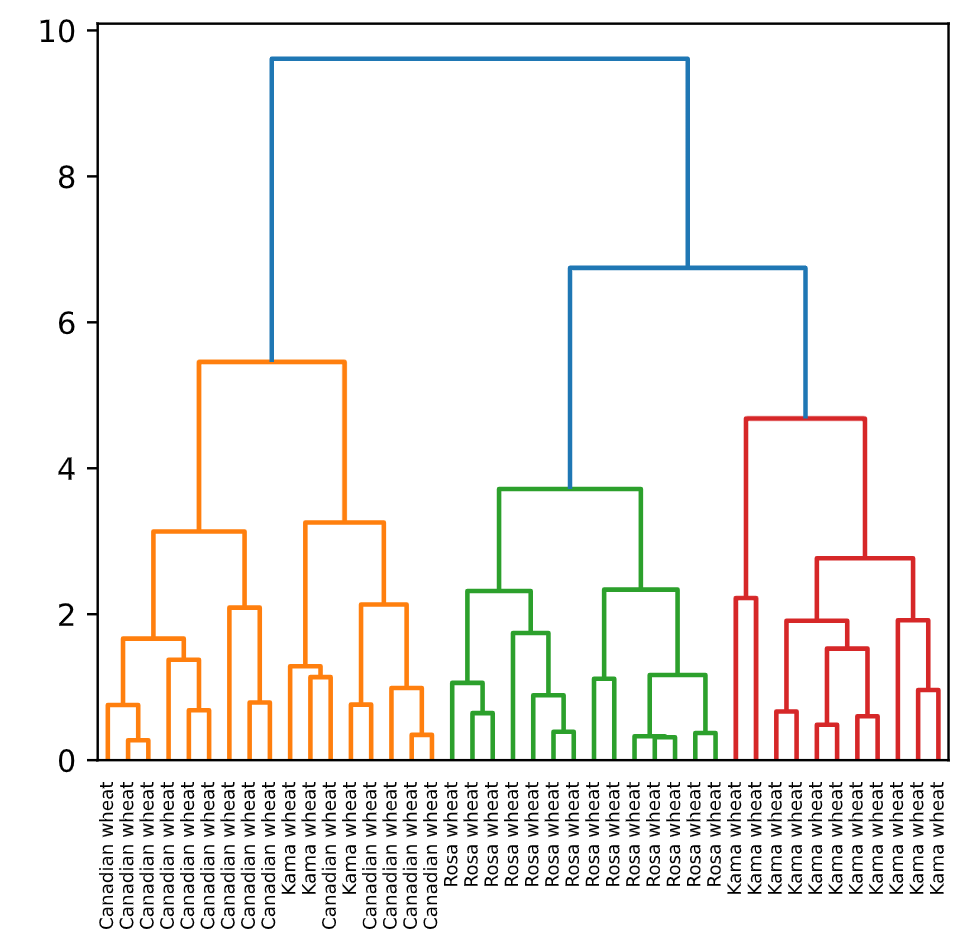

The answer is 3.

เหมือนตัดกิ่งไม้ ถ้าตัดแล้วร่วงลงมากี่ยวง ก็เท่านั้น cluster แหละ เช่น ถ้าตัดที่ 4 ก็จะมี 5 clusters



### ***Exercise: Extracting the cluster labels***

Use the **`fcluster()`** function to extract the cluster labels for this intermediate clustering, and compare the labels with the grain varieties using a cross-tabulation.

The hierarchical clustering has already been performed and mergings is the result of the **`linkage()`** function. The list `varieties` gives the variety of each grain sample.

* Perform a flat hierarchical clustering by using the **`fcluster()`** function on `mergings`. Specify a maximum height of `6` and the keyword argument **`criterion='distance'`**.
* Create a DataFrame `df` with two columns named `'labels'` and `'varieties'`, using `labels` and `varieties`, respectively.

* Create a cross-tabulation `ct` between `df['labels']` and `df['varieties']` to count the number of times each grain variety coincides with each cluster label.

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Use fcluster to extract labels: labels
labels = fcluster(mergings, 6, criterion='distance')

# Create a DataFrame with labels and varieties as columns: df
df = pd.DataFrame({'labels': labels, 'varieties': varieties}).sort_values(by='labels')

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
display(ct)
print("=========================")
display(df)

varieties,Canadian wheat,Kama wheat,Rosa wheat
labels,,,
1,14,3,0
2,0,0,14
3,0,11,0


,labels,varieties
5,1,Kama wheat
8,1,Kama wheat
12,1,Kama wheat
28,1,Canadian wheat
31,1,Canadian wheat
30,1,Canadian wheat
29,1,Canadian wheat
40,1,Canadian wheat
39,1,Canadian wheat
38,1,Canadian wheat


You've now mastered the fundamentals of k-Means and agglomerative hierarchical clustering.

# ***t-SNE in sklearn***

**t**-distributed **S**tochastic **N**eighbor **E**mbedding

* Maps samples from higher dimensional space to 2D space (or 3D)

## **t-SNE on iris dataset**

* Map 4D samples to 2D space
* t-SNE is not given information about species


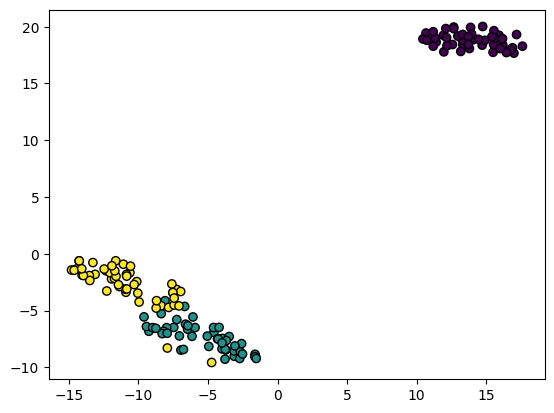

In [ ]:
from sklearn import datasets
from sklearn.manifold import TSNE

samples = datasets.load_iris()['data']
species = datasets.load_iris()['target']

model = TSNE(learning_rate=100)
transformed = model.fit_transform(samples)
plt.scatter(transformed[:, 0], transformed[:, 1], c=species, edgecolor='black')
plt.show()

## **t-SNE has only `fit_transform()`**

## **t-SNE learning rate**

* Try values between 50 and 200
* Wrong choice leads to points bunch together

## **t-SNE plot can look different every time**

### ***Exercise: t-SNE visualization of grain dataset***

Apply t-SNE to the grain samples data and inspect the resulting t-SNE features using a scatter plot. You are given an array `samples` of grain samples and a list `variety_numbers` giving the variety number of each grain sample.

* Create a TSNE instance called model with `learning_rate=200`.
* Apply the `.fit_transform()` method of model to samples. Assign the result to `tsne_features`.
* Make a scatter plot of the t-SNE features.  To color the points by the grain variety, specify the additional keyword argument `c=variety_numbers`.

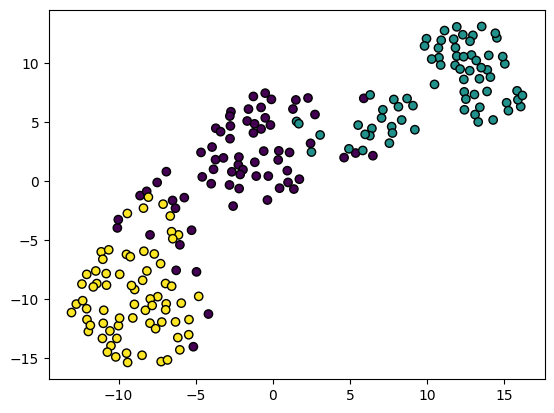

In [ ]:
# Import TSNE
from sklearn.manifold import TSNE

samples = pd.read_csv('seeds.csv', header=None).drop(columns=7).values
variety_numbers = pd.read_csv('seeds.csv', header=None)[7].values

# Create a TSNE instance: model
model = TSNE(learning_rate=200)

# Apply fit_transform to samples: tsne_features
tsne_features = model.fit_transform(samples)

# Select the 0th feature: xs
xs = tsne_features[:,0]

# Select the 1st feature: ys
ys = tsne_features[:,1]

# Scatter plot, coloring by variety_numbers
plt.scatter(xs, ys, c=variety_numbers, edgecolor='black')
plt.show()

As you can see, the t-SNE visualization manages to separate the 3 varieties of grain samples.

### ***Exercise: A t-SNE map of the stock market***

t-SNE provides great visualizations when the individual samples can be labeled. In this exercise, you'll apply t-SNE to the company stock price data. A scatter plot of the resulting t-SNE features, labeled by the company names, gives you a map of the stock market! The stock price movements for each company are available as the array `normalized_movements` (these have already been normalized for you). The list `companies` gives the name of each company.

* Import `TSNE` from `sklearn.manifold`.
* Create a `TSNE` instance called model with `learning_rate=50`.
* Apply the `.fit_transform()` method of model to `normalized_movements`. Assign the result to `tsne_features`.
* Select column `0` and column `1` of `tsne_features`.
* Make a scatter plot of the t-SNE features `xs` and `ys`. Specify the additional keyword argument `alpha=0.5`.
* Code to label each point with its company name has been written for you using `plt.annotate()`.

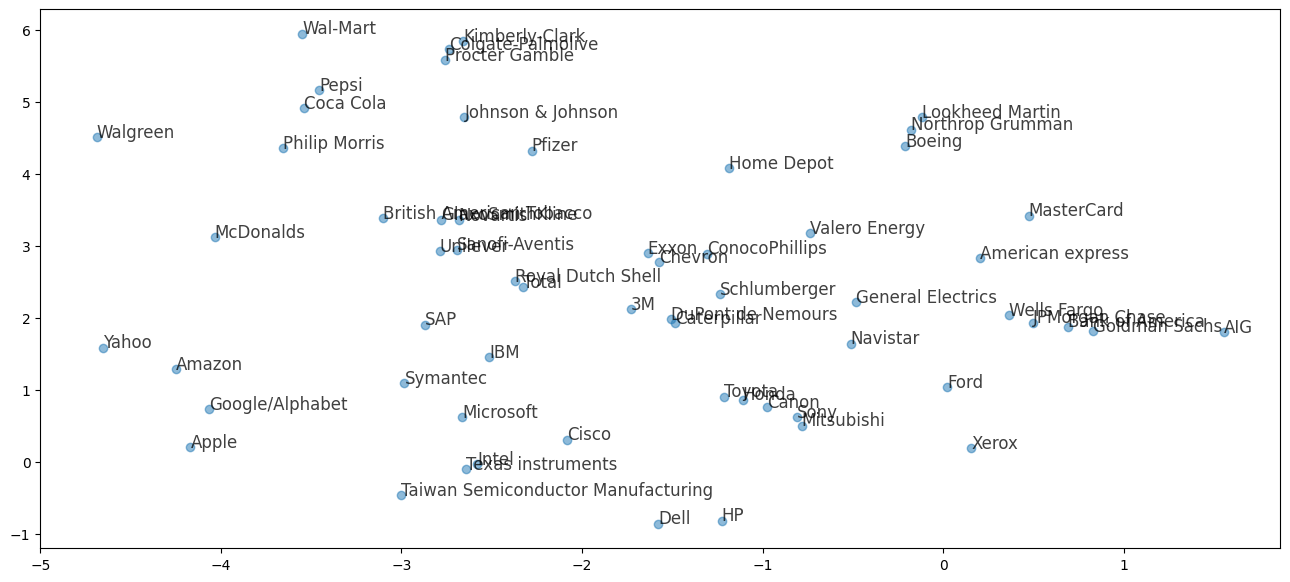

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
fig, ax = plt.subplots(figsize=(16, 7))

movements = pd.read_csv('company-stock-movements-2010-2015-incl.csv').drop(columns='Unnamed: 0').values
companies = pd.read_csv('company-stock-movements-2010-2015-incl.csv')['Unnamed: 0'].values
normalized_movements = normalize(movements)

# Create a TSNE instance: model
model = TSNE(learning_rate=50)

# Apply fit_transform to normalized_movements: tsne_features
tsne_features = model.fit_transform(normalized_movements)

# Select the 0th feature: xs
xs = tsne_features[:, 0]

# Select the 1th feature: ys
ys = tsne_features[:,1]

# Scatter plot
ax.scatter(xs, ys, alpha=0.5)

# Annotate the points
for x, y, company in zip(xs, ys, companies):
    plt.annotate(company, (x, y), fontsize=12, alpha=0.75)
plt.show()

It's visualizations such as this that make t-SNE such a powerful tool for extracting quick insights from high dimensional data.

# **Dimension reduction**

* Rotate data samples to align with axes  
* Shift data samples so they have mean = 0
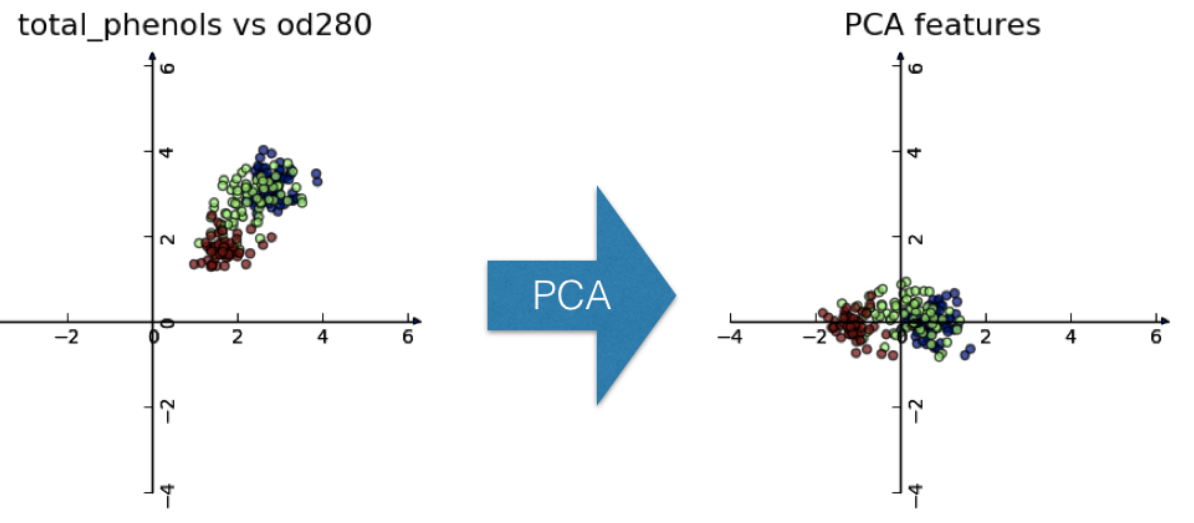





## ***Using scikit-learn PCA***

* อันไหนมีความแปรปรวนเยอะๆ แปลว่าควรเลือกมาเป็นปัจจัยที่เกี่ยวข้อง

* Columns of transformed samples are called PCA features

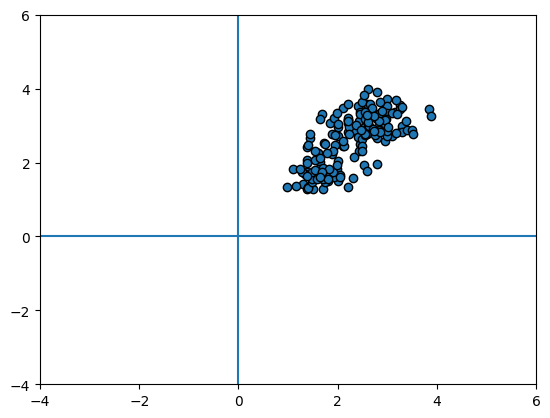

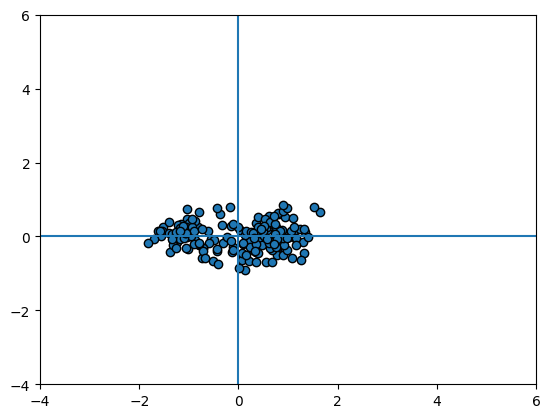

In [ ]:
from sklearn.decomposition import PCA

samples = pd.read_csv('wine.csv')[['total_phenols', 'od280']].values

plt.scatter(samples[:, 0], samples[:, 1], edgecolor='black')
plt.xlim([-4, 6])
plt.ylim([-4, 6])
plt.axvline(x=0)
plt.axhline(y=0)
plt.show()

# model = PCA().fit(samples)
transformed = model.fit_transform(samples)
plt.scatter(transformed[:, 0], transformed[:, 1], edgecolor='black')
plt.xlim([-4, 6])
plt.ylim([-4, 6])
plt.axvline(x=0)
plt.axhline(y=0)
plt.show()

* Samples are positively correlated
* Transformed samples have no correlation

## **Principal components**

* One row for each principal component

In [ ]:
model.components_

array([[ 0.64116665,  0.76740167],
       [ 0.76740167, -0.64116665]])

### ***Exercise: Correlated data in nature***

You are given an array `grains` giving the width and length of samples of grain. You suspect that width and length will be correlated. To confirm this, make a scatter plot of width vs length and measure their Pearson correlation.


* Import `pearsonr` from `scipy.stats`.
* Assign column `0` of `grains` to `width` and column `1` of `grains` to `length`.
* Make a scatter plot with `width` on the x-axis and `length` on the y-axis.
* Use the `pearsonr()` function to calculate the Pearson correlation of `width` and `length`.

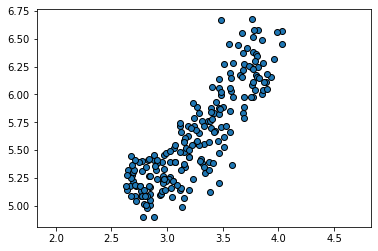

0.8604149377143469


In [ ]:
grains = pd.read_csv('seeds-width-vs-length.csv', header=None).values

# Perform the necessary imports
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Assign the 0th column of grains: width
width = grains[:, 0]

# Assign the 1st column of grains: length
length = grains[:, 1]

# Scatter plot width vs length
plt.scatter(width, length, edgecolor='black')
plt.axis('equal')
plt.show()

# Calculate the Pearson correlation
correlation, pvalue = pearsonr(width, length)

# Display the correlation
print(correlation)

The width and length of the grain samples are highly correlated.

### ***Exercise: Decorrelating the grain measurements with PCA***

You observed in the previous exercise that the width and length measurements of the grain are correlated. Now, you'll use PCA to decorrelate these measurements, then plot the decorrelated points and measure their Pearson correlation.

* Import `PCA` from `sklearn.decomposition`.
* Create an instance of PCA called `model`.
* Use the `.fit_transform()` method of model to apply the PCA transformation to `grains`. Assign the result to `pca_features`.


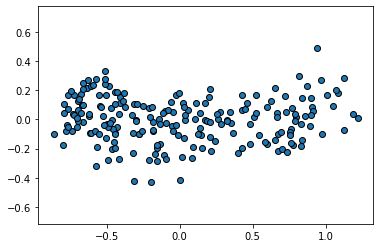

8.933825901280557e-17


In [ ]:
from sklearn.decomposition import PCA

# Create PCA instance: model
model = PCA()

# Apply the fit_transform method of model to grains: pca_features
pca_features = model.fit_transform(grains)

# Assign 0th column of pca_features: xs
xs = pca_features[:,0]

# Assign 1st column of pca_features: ys
ys = pca_features[:,1]

# Scatter plot xs vs ys
plt.scatter(xs, ys, edgecolor='black')
plt.axis('equal')
plt.show()

# Calculate the Pearson correlation of xs and ys
correlation, pvalue = pearsonr(xs, ys)

# Display the correlation
print(correlation)

# **Intrinsic dimension**

* Data of 2 dimension
* But can be approximated by just one feature (1 dimension)

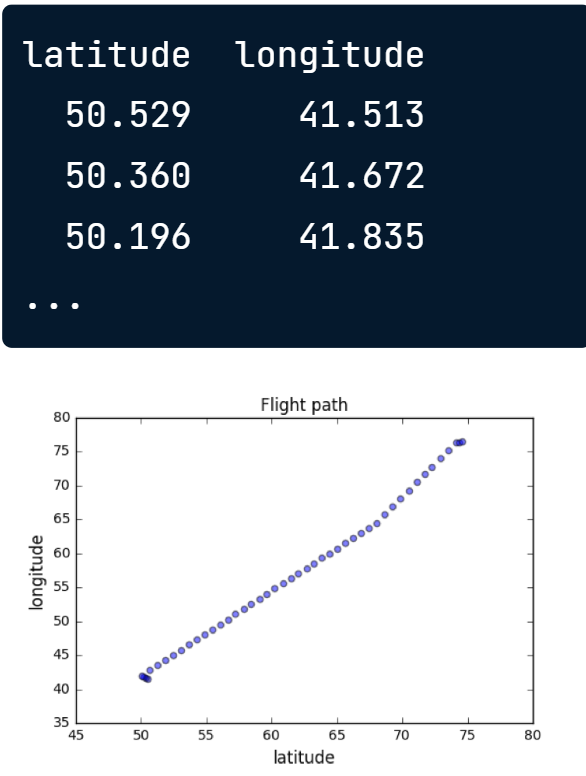

* Intrinsic dimension = number of PCA features with significant variance

In [ ]:
df = pd.DataFrame(data=np.concatenate([samples, species.reshape(-1, 1)], axis=1), columns=['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'Species'])
df['Species'] = df['Species'].astype(int)
df = df[df['Species']==1]
samples = df[['Sepal length', 'Sepal width', 'Petal width']].values

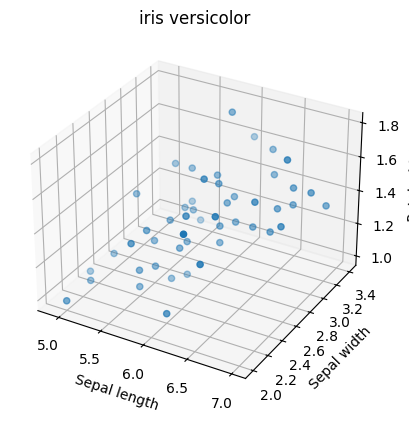

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # enables 3D plotting
import numpy as np

samples = datasets.load_iris()['data']
species = datasets.load_iris()['target']
df = pd.DataFrame(data=np.concatenate([samples, species.reshape(-1, 1)], axis=1), columns=['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'Species'])
df['Species'] = df['Species'].astype(int)
df = df[df['Species']==1]
samples = df[['Sepal length', 'Sepal width', 'Petal width']].values

# Create 3D figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2])

# Labels (optional)
ax.set_xlabel('Sepal length')
ax.set_ylabel('Sepal width')
ax.set_zlabel('Petal width')

plt.title('iris versicolor')
plt.show()


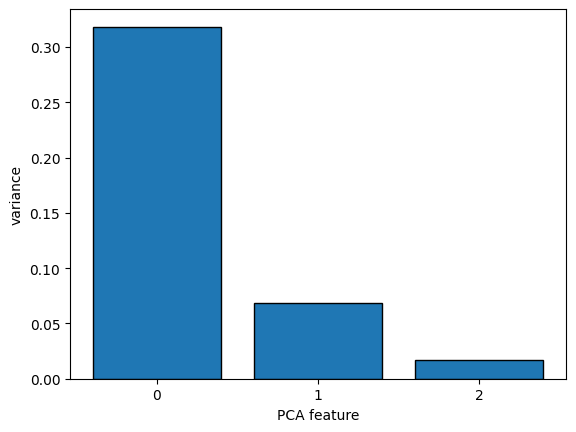

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(samples)
features = range(pca.n_components_)

plt.bar(features, pca.explained_variance_, edgecolor='black')
plt.xticks(features)
plt.ylabel('variance')
plt.xlabel('PCA feature')
plt.show()

## ***Plotting the variances of PCA features***

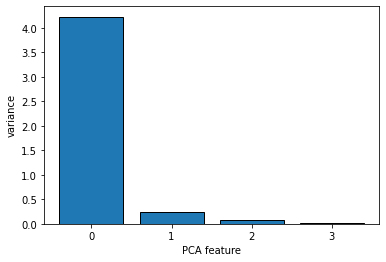

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(samples)
features = range(pca.n_components_)

plt.bar(features, pca.explained_variance_, edgecolor='black')
plt.xticks(features)
plt.ylabel('variance')
plt.xlabel('PCA feature')
plt.show()

### ***Exercise: The first principal component***

The first principal component of the data is the direction in which the data varies the most. In this exercise, your job is to use PCA to find the first principal component of the `length` and `width` measurements of the grain samples, and represent it as an arrow on the scatter plot.

The array `grains` gives the `length` and `width` of the grain samples.

* Make a scatter plot of the grain measurements.
* Create a PCA instance called `model`.
* Fit the model to the `grains` data.
* Extract the coordinates of the mean of the data using the **`.mean_ attribute`** of `model`.
* Get the first principal component of model using the **`.components_[0,:]`** attribute.
* Plot the first principal component as an arrow on the scatter plot, using the **`plt.arrow()`** function. You have to specify the first two arguments - `mean[0]` and `mean[1]`.

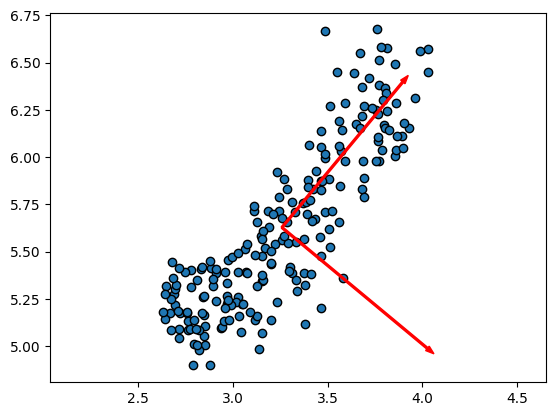

In [ ]:
grains = pd.read_csv('seeds-width-vs-length.csv', header=None).values

# Make a scatter plot of the untransformed points
plt.scatter(grains[:,0], grains[:,1], edgecolor='black')

# Create a PCA instance: model
model = PCA()

# Fit model to points
model.fit(grains)

# Get the mean of the grain samples: mean
mean = model.mean_

# Get the first principal component: first_pc
first_pc = model.components_[0,:]
second_pc = model.components_[1,:]
# Plot first_pc as an arrow, starting at mean
plt.arrow(mean[0], mean[1], first_pc[0], first_pc[1], color='red', width=0.01)
plt.arrow(mean[0], mean[1], second_pc[0], second_pc[1], color='red', width=0.01)
# Keep axes on same scale
plt.axis('equal')
plt.show()

### ***Exercise: Variance of the PCA features***

The fish dataset is 6-dimensional. But what is its intrinsic dimension? Make a plot of the variances of the PCA features to find out. As before, `samples` is a 2D array, where each row represents a fish. You'll need to standardize the features first.

* Create an instance of `StandardScaler` called `scaler`.
* Create a `PCA` instance called `pca`.
* Use the `make_pipeline()` function to create a pipeline chaining `scaler` and `pca`.
* Use the `.fit()` method of `pipeline` to fit it to the fish samples `samples`.
* Extract the number of components used using the `.n_components_` attribute of `pca`. Place this inside a `range()` function and store the result as `features`.
* Use the `plt.bar()` function to plot the explained variances, with `features` on the x-axis and `pca.explained_variance_` on the y-axis.

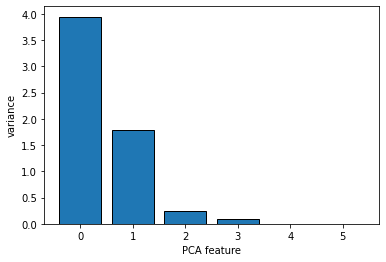

In [ ]:
# Perform the necessary imports
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

samples = pd.read_csv('fish.csv', header=None).drop(columns=0).values

# Create scaler: scaler
scaler = StandardScaler()

# Create a PCA instance: pca
pca = PCA()

# Create pipeline: pipeline
pipeline = make_pipeline(scaler, pca)

# Fit the pipeline to 'samples'
pipeline.fit(samples)

# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_, edgecolor='black')
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.xticks(features)
plt.show()

# **Dimension reduction**

* Represents same data using less features (less independent variables)

## ***Dimension reduction with PCA***

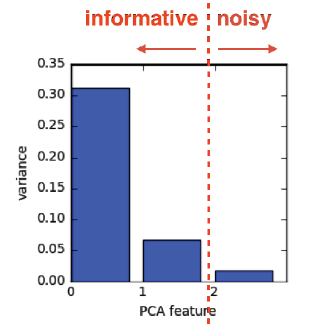

* Specify how many features to keep
* E.g. `PCA(n_components=2)`
* Keeps the first 2 PCA features

In [ ]:
from sklearn.decomposition import PCA

# Iris dataset

pca = PCA(n_components=2)
pca.fit(samples)
transformed = pca.transform(samples)
transformed.shape

(150, 2)

PCA has reduced the dimension to 2 (with highest variances)

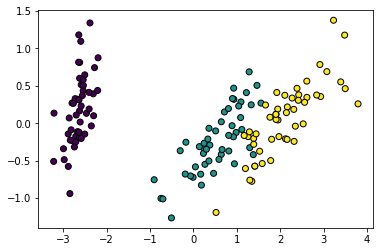

In [ ]:
plt.scatter(transformed[:,0], transformed[:,1], c=species, edgecolor='black')
plt.show()

# **Word frequency arrays**

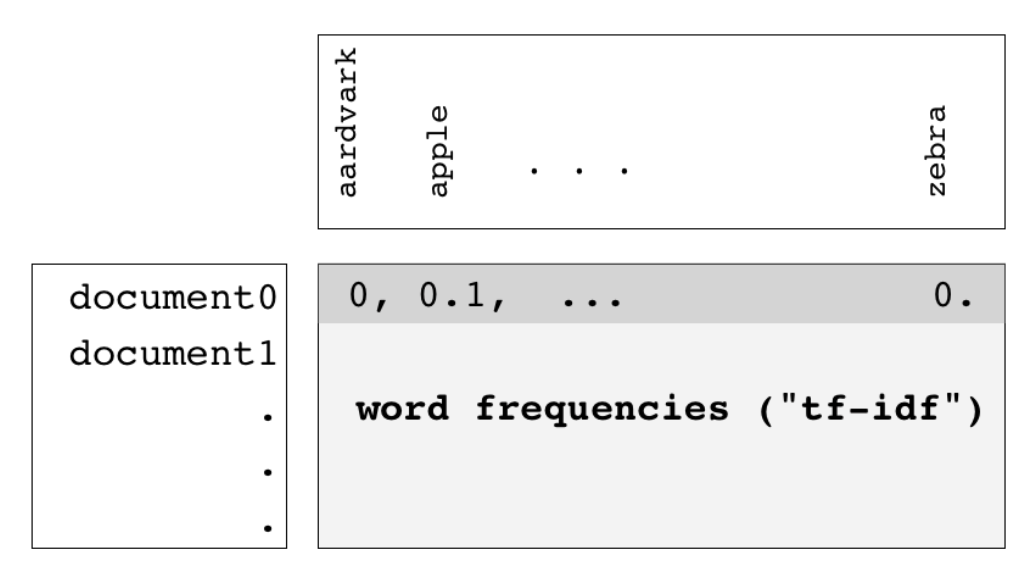

## ***Sparse arrays and csr_matrix***

* **"Sparse"**: most entries are zero
* Can use **`scipy.sparse.csr_matrix`** instead of NumPy array
* `csr_matrix` remembers only the non-zero entries (saves space!)

## ***TruncatedSVD and csr_matrix***

* scikit-learn PCA doesn't support `csr_matrix`
* Use scikit-learn **`TruncatedSVD`** instead
* Performs same transformation



In [ ]:
from sklearn.decomposition import TruncatedSVD

model = TruncatedSVD(n_components=3)
model.fit(documents) # documents is csr_matrix
TruncatedSVD(algorithm='randomized', ... )
transformed = model.transform(documents)

### ***Exercise: Dimension reduction of the fish measurements***

In a previous exercise, you saw that 2 was a reasonable choice for the "intrinsic dimension" of the fish measurements. Now use PCA for dimensionality reduction of the fish measurements, retaining only the 2 most important components.

The fish measurements have already been scaled for you, and are available as `scaled_samples`.

* Import `PCA` from `sklearn.decomposition`.
* Create a `PCA` instance called `pca` with `n_components=2`.
* Use the `.fit()` method of `pca` to fit it to the scaled fish measurements `scaled_samples`.
* Use the `.transform()` method of `pca` to transform the `scaled_samples`. Assign the result to `pca_features`.

In [ ]:
from sklearn.decomposition import PCA

samples = pd.read_csv('fish.csv', header=None).drop(columns=0).values
species = pd.read_csv('fish.csv', header=None)[0].to_list()

scaler = StandardScaler()
scaler.fit(samples)
StandardScaler(copy=True, with_mean=True, with_std=True)
scaled_samples = scaler.transform(samples)
print(scaled_samples.shape)

# Create a PCA model with 2 components: pca
pca = PCA(n_components=2)

# Fit the PCA instance to the scaled samples
pca.fit(scaled_samples)

# Transform the scaled samples: pca_features
pca_features = pca.transform(scaled_samples)

# Print the shape of pca_features
print(pca_features.shape)

(85, 6)
(85, 2)


You've successfully reduced the dimensionality from 6 to 2.

### ***Exercise: A tf-idf word-frequency array***

Create a tf-idf word frequency array for a toy collection of documents. For this, use the **`TfidfVectorizer`** from **`sklearn`**. It transforms a list of documents into a word frequency array, which it outputs as a **`csr_matrix`**. It has **`fit()`** and **`transform()`** methods like other `sklearn` objects.

You are given a list `documents` of toy documents about pets.

* Import `TfidfVectorizer` from `sklearn.feature_extraction.text`.
Create a `TfidfVectorizer` instance called `tfidf`.

* Apply `.fit_transform()` method of `tfidf` to documents and assign the result to `csr_mat`. This is a word-frequency array in `csr_matrix` format.

* Inspect `csr_mat` by calling its `.toarray()` method and printing the result.

* The columns of the array correspond to words. Get the list of words by calling the `.get_feature_names()` method of `tfidf`, and assign the result to words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = ['cats say meow', 'dogs say woof', 'dogs chase cats']

# Create a TfidfVectorizer: tfidf
tfidf = TfidfVectorizer()

# Apply fit_transform to document: csr_mat
csr_mat = tfidf.fit_transform(documents)

# Print result of toarray() method
print(csr_mat.toarray())

# Get the words: words
words = tfidf.get_feature_names()

# Print words
print(words)


[[0.51785612 0.         0.         0.68091856 0.51785612 0.        ]
 [0.         0.         0.51785612 0.         0.51785612 0.68091856]
 [0.51785612 0.68091856 0.51785612 0.         0.         0.        ]]
['cats', 'chase', 'dogs', 'meow', 'say', 'woof']


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


### ***Exercise: Clustering Wikipedia part I***

`TruncatedSVD` is able to perform PCA on sparse arrays in `csr_matrix` format, such as word-frequency arrays. Combine your knowledge of TruncatedSVD and k-means to cluster some popular pages from Wikipedia. In this exercise, build the pipeline.

Create a Pipeline object consisting of a TruncatedSVD followed by KMeans. (This time, we've precomputed the word-frequency matrix for you, so there's no need for a TfidfVectorizer).

The Wikipedia dataset you will be working with was obtained from [here](https://blog.lateral.io/2015/06/the-unknown-perils-of-mining-wikipedia/).

* Import:
  * `TruncatedSVD` from `sklearn.decomposition`.
  * `KMeans` from `sklearn.cluster`.
  * `make_pipeline` from `sklearn.pipeline`.

* Create a `TruncatedSVD` instance called `svd` with `n_components=50`.
* Create a `KMeans` instance called `kmeans` with `n_clusters=6`.
* Create a pipeline called `pipeline` consisting of `svd` and `kmeans`.

In [ ]:
# Perform the necessary imports
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

# Create a TruncatedSVD instance: svd
svd = TruncatedSVD(n_components=50)

# Create a KMeans instance: kmeans
kmeans = KMeans(n_clusters=6)

# Create a pipeline: pipeline
pipeline = make_pipeline(svd, kmeans)

### ***Exercise: Clustering Wikipedia part II***

It is now time to put your pipeline from the previous exercise to work! You are given an array `articles` of tf-idf word-frequencies of some popular Wikipedia articles, and a list `titles` of their titles. Use your pipeline to cluster the Wikipedia articles.

A solution to the previous exercise has been pre-loaded for you, so a Pipeline `pipeline` chaining TruncatedSVD with KMeans is available.

* Fit the pipeline to the word-frequency array `articles`.
* Predict the cluster labels.
* Align the cluster labels with the list `titles` of article titles by creating a DataFrame `df` with `labels` and `titles` as columns.
* Use the `.sort_values()` method of `df` to sort the DataFrame by the `'label'` column, and print the result.

```
articles = <Compressed Sparse Row sparse matrix of dtype 'float64'
             with 42091 stored elements and shape (60, 13125)>

titles[:5] = ['HTTP 404',
              'Alexa Internet',
              'Internet Explorer',
              'HTTP cookie',
              'Google Search']

len(titles) = 60
```

In [ ]:
# หน้าตาดูแล้วเหมือนมาจาก TfidfVectorizer ... แต่ไม่น่าใช่
# 13,125 เป็นจำนวน words จาก wiki articles ส่วน 60 คือจำนวนหัวข้อเรื่อง
# ถ้าเป็น TFidfVectorizer จำนวนแถวคือจำนวนเอกสาร จำนวนคอลัมน์คือจำนวนคำ
# แล้ว wikipedia-vectors.csv หามาได้อย่างไร ?

display(pd.read_csv('wikipedia-vectors.csv').drop(columns='Unnamed: 0').head())

print(f"The number of rows and columns from 'wikipedia-vectors.csv' are: \
{pd.read_csv('wikipedia-vectors.csv').drop(columns='Unnamed: 0').shape}")


,HTTP 404,Alexa Internet,Internet Explorer,HTTP cookie,Google Search,Tumblr,Hypertext Transfer Protocol,Social search,Firefox,LinkedIn,...,Chad Kroeger,Nate Ruess,The Wanted,Stevie Nicks,Arctic Monkeys,Black Sabbath,Skrillex,Red Hot Chili Peppers,Sepsis,Adam Levine
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.008878,0.0,0.0,0.049502,0.000000,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00611,0.0
2,0.0,0.029607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.005646,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.0


The number of rows and columns from 'wikipedia-vectors.csv' are: (13125, 60)


In [ ]:
articles = pd.read_csv('wikipedia-vectors.csv').drop(columns='Unnamed: 0')#.values.T
display(articles.columns)
articles.shape

Index(['HTTP 404', 'Alexa Internet', 'Internet Explorer', 'HTTP cookie',
       'Google Search', 'Tumblr', 'Hypertext Transfer Protocol',
       'Social search', 'Firefox', 'LinkedIn', 'Global warming',
       'Nationally Appropriate Mitigation Action', 'Nigel Lawson',
       'Connie Hedegaard', 'Climate change', 'Kyoto Protocol', '350.org',
       'Greenhouse gas emissions by the United States',
       '2010 United Nations Climate Change Conference',
       '2007 United Nations Climate Change Conference', 'Angelina Jolie',
       'Michael Fassbender', 'Denzel Washington', 'Catherine Zeta-Jones',
       'Jessica Biel', 'Russell Crowe', 'Mila Kunis', 'Dakota Fanning',
       'Anne Hathaway', 'Jennifer Aniston', 'France national football team',
       'Cristiano Ronaldo', 'Arsenal F.C.', 'Radamel Falcao',
       'Zlatan Ibrahimović', 'Colombia national football team',
       '2014 FIFA World Cup qualification', 'Football', 'Neymar',
       'Franck Ribéry', 'Tonsillitis', 'Hepatitis B', '

(13125, 60)

ถ้าเป็นแบบนี้ `articles` ก็จะมีรูปร่างที่เข้ากันได้กับไฟล์ที่มาจาก transpose ของ `TfidfVectorizer`

`TfidfVectorizer` จำนวนแถวเท่ากับ 60 คือจำนวนหัวข้อเรื่อง และ จำนวนคอลัมน์เท่ากับ 13,125 คือคำที่มาจากในเรื่อง

แต่ `'wikipedia-vectors.csv'` ไม่มีคำมาให้



In [ ]:
from scipy.sparse import csr_matrix

articles = pd.read_csv('wikipedia-vectors.csv').drop(columns='Unnamed: 0').values.T
articles = csr_matrix(articles) # ไม่ต้องใช้ก็ได้ ตัว TruncatedSVD ใช้ตัวบนก็ได้เหมือนกัน

# คำถาม? รู้ได้ยังไงว่าหัวข้อเหล่านี้มันไปตรงกับ labels อะไร
# คำตอบ อันนี้รู้ได้จาก KMeans clustering

# ปกติ คำที่มาจาก TfidfVectorizer().fit_transform(textdata).get_feature_names_out()
# จะเป็น bag of words

titles = ['HTTP 404', 'Alexa Internet', 'Internet Explorer', 'HTTP cookie', 'Google Search', 'Tumblr', 'Hypertext Transfer Protocol', 'Social search', 'Firefox', 'LinkedIn', 'Global warming', 'Nationally Appropriate Mitigation Action', 'Nigel Lawson', 'Connie Hedegaard', 'Climate change', 'Kyoto Protocol', '350.org', 'Greenhouse gas emissions by the United States', '2010 United Nations Climate Change Conference', '2007 United Nations Climate Change Conference', 'Angelina Jolie', 'Michael Fassbender', 'Denzel Washington', 'Catherine Zeta-Jones', 'Jessica Biel', 'Russell Crowe', 'Mila Kunis', 'Dakota Fanning', 'Anne Hathaway', 'Jennifer Aniston', 'France national football team', 'Cristiano Ronaldo', 'Arsenal F.C.', 'Radamel Falcao', 'Zlatan Ibrahimović', 'Colombia national football team', '2014 FIFA World Cup qualification', 'Football', 'Neymar', 'Franck Ribéry', 'Tonsillitis', 'Hepatitis B', 'Doxycycline', 'Leukemia', 'Gout', 'Hepatitis C', 'Prednisone', 'Fever', 'Gabapentin', 'Lymphoma', 'Chad Kroeger', 'Nate Ruess', 'The Wanted', 'Stevie Nicks', 'Arctic Monkeys', 'Black Sabbath', 'Skrillex', 'Red Hot Chili Peppers', 'Sepsis', 'Adam Levine']

# Fit the pipeline to articles
pipeline.fit(articles)

# Calculate the cluster labels: labels
labels = pipeline.predict(articles)

# Create a DataFrame aligning labels and titles: df
df = pd.DataFrame({'label': labels, 'article': titles})

# Display df sorted by cluster label
display(df.sort_values(by='label'))


,label,article
12,0,Nigel Lawson
0,1,HTTP 404
6,1,Hypertext Transfer Protocol
3,1,HTTP cookie
52,1,The Wanted
53,1,Stevie Nicks
54,1,Arctic Monkeys
55,1,Black Sabbath
40,1,Tonsillitis
41,1,Hepatitis B


# ***Non-negative matrix factorization***

* Dimension reduction technique
* NMF models are interpretable (unlike PCA)
* Easy to interpret means easy to explain!
* However, all sample features must be non-negative (>= 0)
* Must specify number of components e.g. `NMF(n_components=2)`

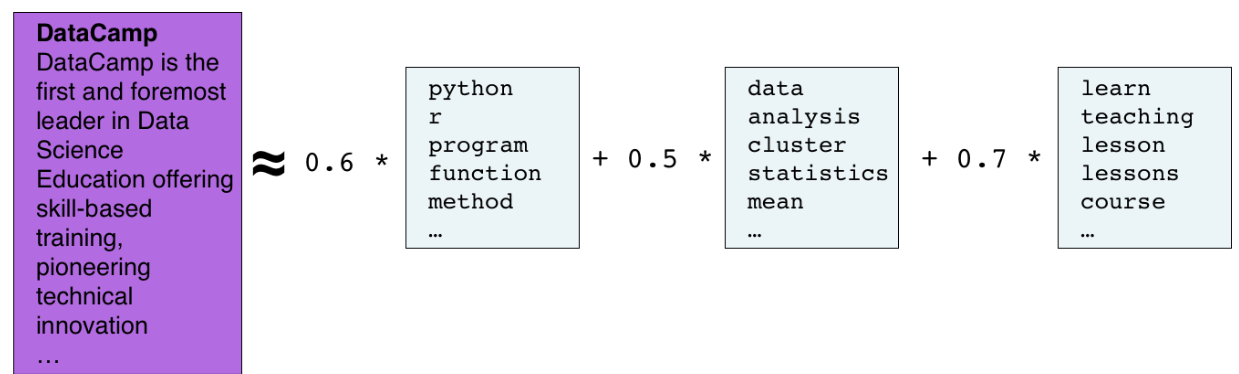

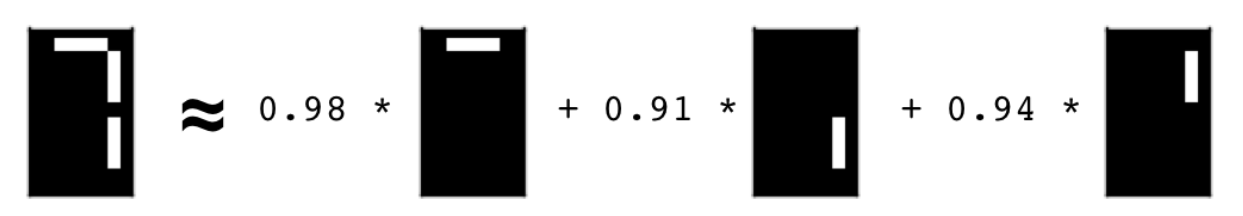

## **Example: word-frequency array**

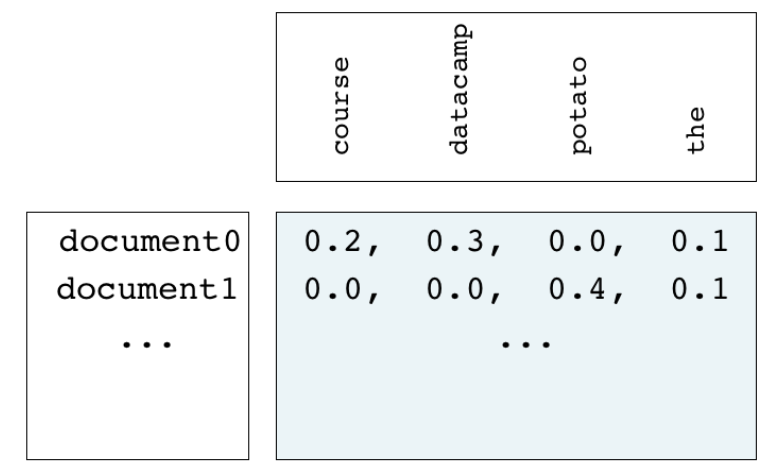



In [ ]:
from sklearn.decomposition import NMF

# Unlike PCA, n_components must always be specified
model = NMF(n_components=2)
model.fit(samples)
nmf_features = model.transform(samples)
print(model.components_)

```
[[ 0.01 0. 2.13 0.54]
 [ 0.99 1.47 0. 0.5 ]]
```

* 2 components
* 4 dimensions (same as samples)

In [ ]:
print(nmf_features)

```
[[ 0. 0.2 ]
 [ 0.19 0.]
 ...
 [ 0.15 0.12]]
```

* Features จาก NMF ที่ถูกสร้างขึ้นมาใหม่
* Can be combined to approximately reconstruct the original data

* Features จะมีจำนวนแถว = samples จำนวนคอลัมน์ = `n_components`
* Components จะมีจำนวนแถว = `n_components` จำนวนคอลัมน์ = คอลัมน์ของ samples

## **Reconstruction of samples**

In [ ]:
print(samples[i,:])

```
[ 0.12 0.18 0.32 0.14]
```

In [ ]:
print(nmf_features[i,:])

```
[ 0.15 0.12]
```

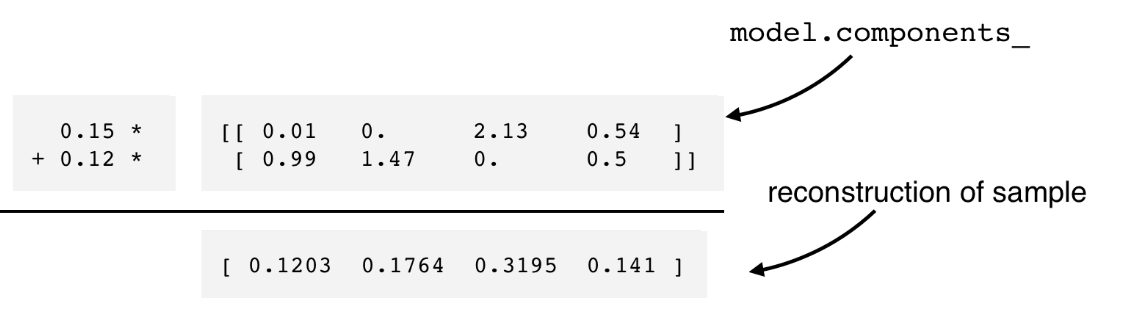

### **Question: Non-negative data**

Which of the following 2-dimensional arrays are examples of non-negative data?

1. A tf-idf word-frequency array.
2. An array daily stock market price movements (up and down), where each row represents a company.
3. An array where rows are customers, columns are products and entries are 0 or 1, indicating whether a customer has purchased a product.

### **Answer**

Stock prices can go down as well as up, so an array of daily stock market price movements is not an example of non-negative data.

### ***Exercise: NMF applied to Wikipedia articles***

Apply NMF to the tf-idf word-frequency array of Wikipedia articles, given as a csr matrix `articles`. Here, fit the model and transform the articles.

* Import `NMF` from `sklearn.decomposition`.
* Create an `NMF` instance called `model` with `6` components.
* Fit the model to the word count data `articles`.
* Use the `.transform()` method of `model` to transform `articles`, and assign the result to `nmf_features`.
* Print `nmf_features` to get a first idea what it looks like (`.round(2)` rounds the entries to 2 decimal places.)

In [ ]:
from sklearn.decomposition import NMF
from scipy.sparse import csr_matrix

articles = pd.read_csv('wikipedia-vectors.csv').drop(columns='Unnamed: 0').values.T
articles = csr_matrix(articles)

# Create an NMF instance: model
model = NMF(n_components=6)

# Fit the model to articles
# articles มาจาก cell ข้างบน
model.fit(articles)

# Transform the articles: nmf_features
nmf_features = model.transform(articles)

# Print the NMF features
print(nmf_features.round(2))

[[0.   0.   0.   0.   0.   0.44]
 [0.   0.   0.   0.   0.   0.56]
 [0.   0.   0.   0.   0.   0.4 ]
 [0.   0.   0.   0.   0.   0.38]
 [0.   0.   0.   0.   0.   0.48]
 [0.01 0.01 0.01 0.03 0.   0.33]
 [0.   0.   0.02 0.   0.01 0.36]
 [0.   0.   0.   0.   0.   0.49]
 [0.02 0.01 0.   0.02 0.03 0.48]
 [0.01 0.03 0.03 0.07 0.02 0.34]
 [0.   0.   0.53 0.   0.03 0.  ]
 [0.   0.   0.35 0.   0.   0.  ]
 [0.01 0.01 0.31 0.06 0.01 0.02]
 [0.   0.01 0.34 0.01 0.   0.  ]
 [0.   0.   0.43 0.   0.04 0.  ]
 [0.   0.   0.48 0.   0.   0.  ]
 [0.01 0.02 0.37 0.03 0.   0.01]
 [0.   0.   0.48 0.   0.   0.  ]
 [0.   0.01 0.55 0.   0.   0.  ]
 [0.   0.   0.46 0.   0.   0.  ]
 [0.   0.01 0.02 0.51 0.06 0.01]
 [0.   0.   0.   0.51 0.   0.  ]
 [0.   0.01 0.   0.42 0.   0.  ]
 [0.   0.   0.   0.43 0.   0.  ]
 [0.   0.   0.   0.49 0.   0.  ]
 [0.1  0.09 0.   0.38 0.   0.01]
 [0.   0.   0.   0.57 0.   0.01]
 [0.01 0.01 0.   0.47 0.   0.01]
 [0.   0.   0.   0.57 0.   0.  ]
 [0.   0.   0.   0.52 0.01 0.01]
 [0.   0.4

In [ ]:
print(nmf_features.shape)
print(model.components_.shape)
model.components_

(60, 6)
(6, 13125)


array([[1.15078219e-02, 1.22373855e-03, 0.00000000e+00, ...,
        0.00000000e+00, 4.28314595e-04, 0.00000000e+00],
       [0.00000000e+00, 9.60819588e-06, 5.69498482e-03, ...,
        2.82857569e-03, 2.99003377e-04, 0.00000000e+00],
       [0.00000000e+00, 8.34958836e-06, 0.00000000e+00, ...,
        0.00000000e+00, 1.43972351e-04, 0.00000000e+00],
       [4.17500003e-03, 0.00000000e+00, 3.07626859e-03, ...,
        1.75350029e-03, 6.76440555e-03, 0.00000000e+00],
       [0.00000000e+00, 5.70814490e-04, 4.93895260e-03, ...,
        1.92463156e-04, 1.35728026e-03, 0.00000000e+00],
       [1.38898747e-04, 0.00000000e+00, 8.78504481e-03, ...,
        2.41081625e-03, 1.68933091e-03, 0.00000000e+00]])

### ***Exercise: NMF features of the Wikipedia articles***

Now you will explore the NMF features you created in the previous exercise. A solution to the previous exercise has been pre-loaded, so the array `nmf_features` is available. Also available is a list `titles` giving the title of each Wikipedia article.

When investigating the features, notice that for both actors, the NMF feature 3 has by far the highest value. This means that both articles are reconstructed using mainly the 3rd NMF component.

* Create a DataFrame `df` from `nmf_features` using `pd.DataFrame()`. Set the index to `titles` using `index=titles`.

* Use the `.loc[]` accessor of `df` to select the row with title `'Anne Hathaway'`, and print the result. These are the NMF features for the article about the actress Anne Hathaway.
* Repeat the last step for `'Denzel Washington'` (another actor).

In [ ]:
# Create a pandas DataFrame: df
df = pd.DataFrame(data=nmf_features, index=titles)

# Print the row for 'Anne Hathaway'
print(df.loc['Anne Hathaway'])

# Print the row for 'Denzel Washington'
print(df.loc['Denzel Washington'])

0    0.003815
1    0.000000
2    0.000000
3    0.571838
4    0.000000
5    0.000000
Name: Anne Hathaway, dtype: float64
0    0.000000
1    0.005575
2    0.000000
3    0.419543
4    0.000000
5    0.000000
Name: Denzel Washington, dtype: float64


Notice that for both actors, the NMF feature 3 has by far the highest value. This means that both articles are reconstructed using mainly the 3rd NMF component.  You'll see why: NMF components represent topics (for instance, acting!).

### **Question: NMF reconstructs samples**

In this exercise, you'll check your understanding of how NMF reconstructs samples from its components using the NMF feature values. The components of an NMF model are given. If the NMF feature values of a sample are

```
[2, 1]
```

The components of the model is  
```
[[1. , 0.5, 0. ],
 [0.2, 0.1, 2.1]]
```
The original samples is

### **Answer**

```
2*[1. , 0.5, 0. ] + 1*[0.2, 0.1, 2.1]  = [2.2, 1.1, 2.1]
```

# **NMF learns interpretable parts**

* 20,000 articles (rows)
* 800 words (columns)



```
articles.shape = (20000, 800)
```



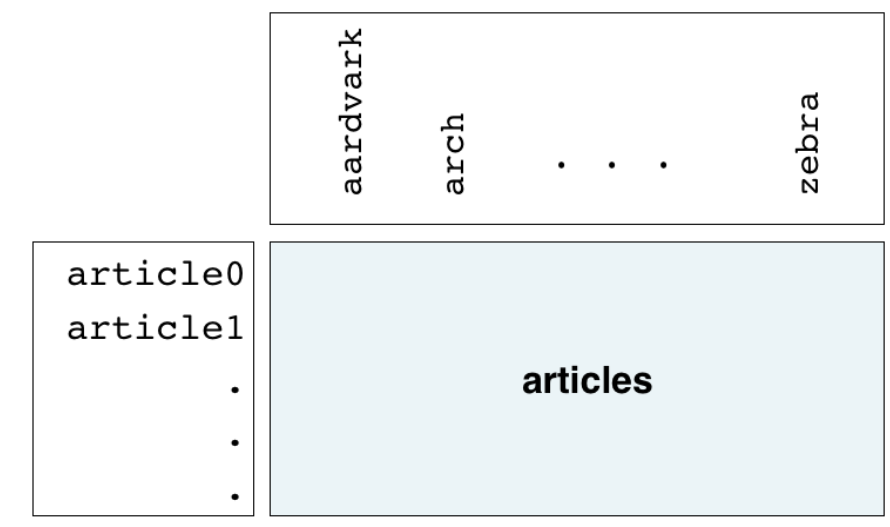

In [ ]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=10).fit(articles)
print(nmf.components_.shape)



```
(10, 800)
```



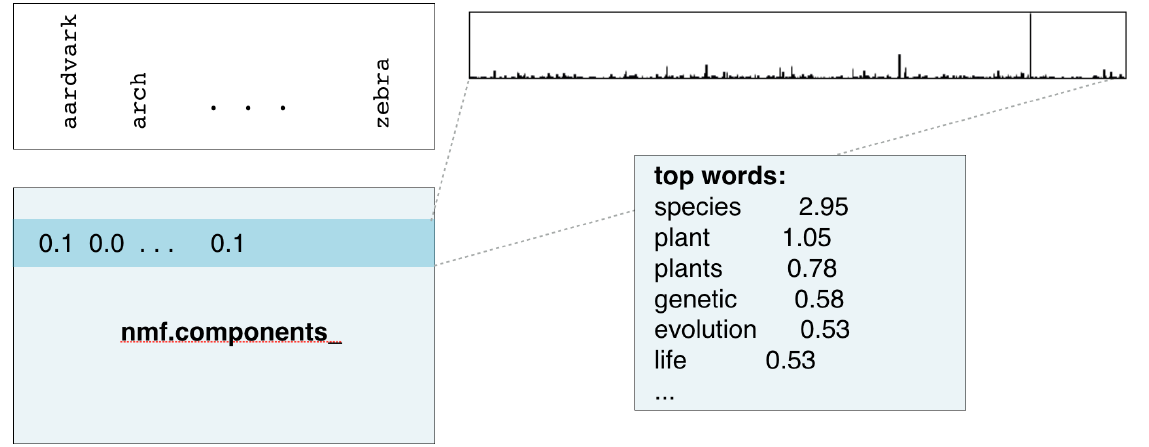

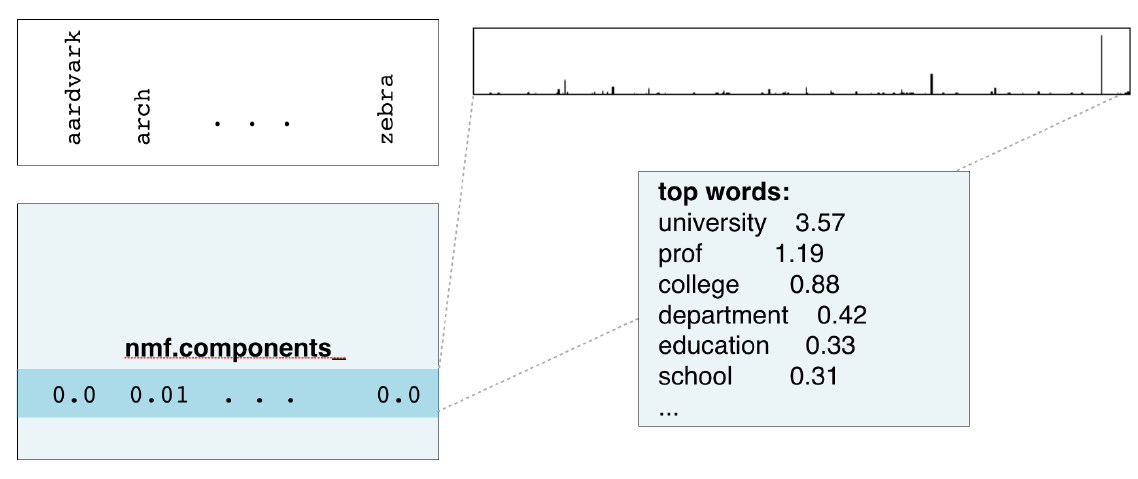

## **NMF components**

For documents:
* NMF components represent topics
* NMF features combine topics into documents

## **Grayscale Images**

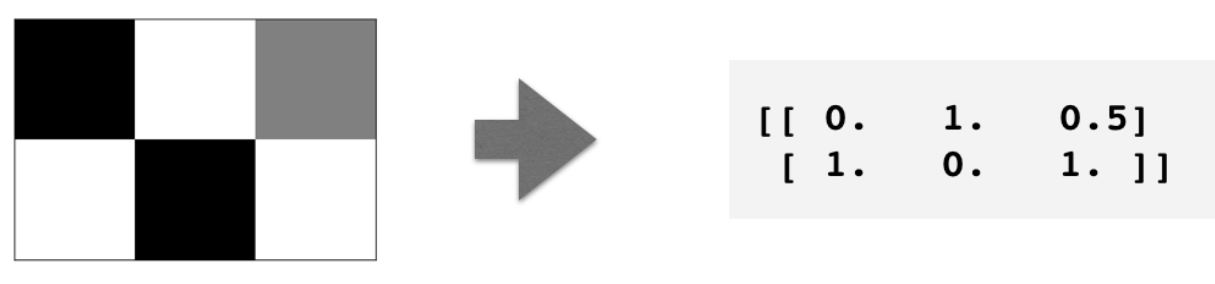

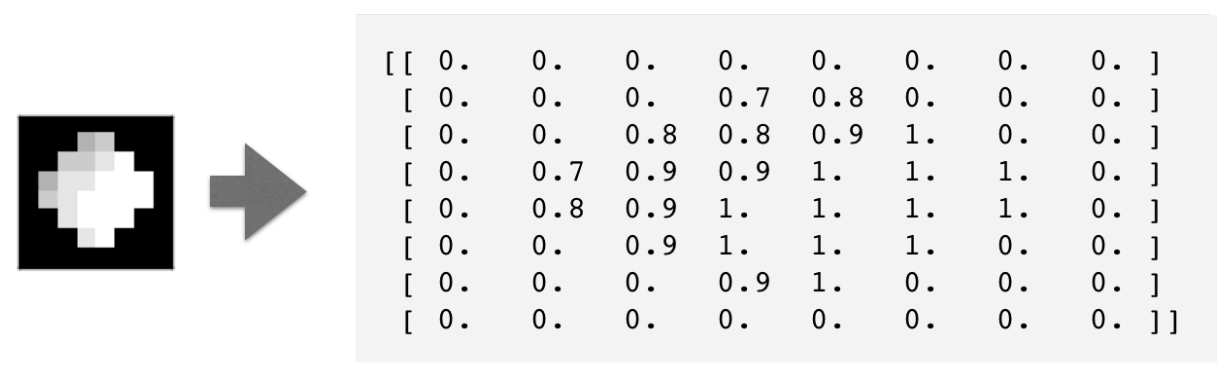

## **Collection of images**

* 1 images is collected in flattened array

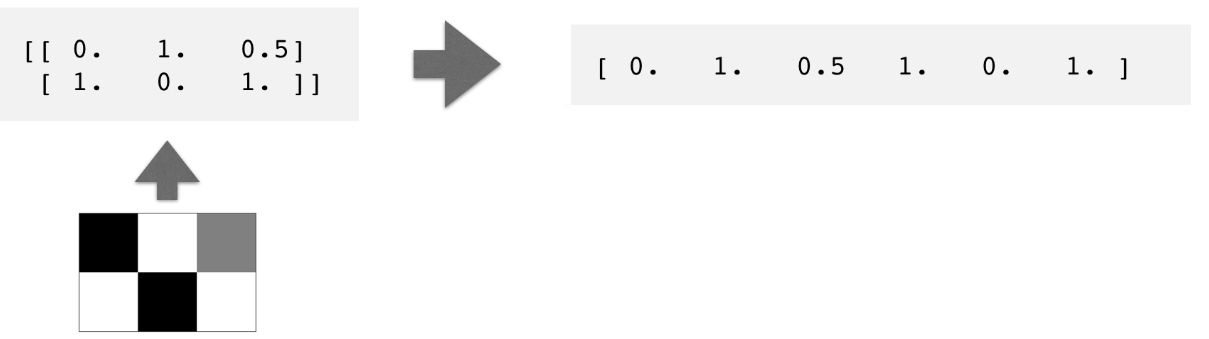

* A collection of images ...

   * Each row is an image
   * Each column is pixel

   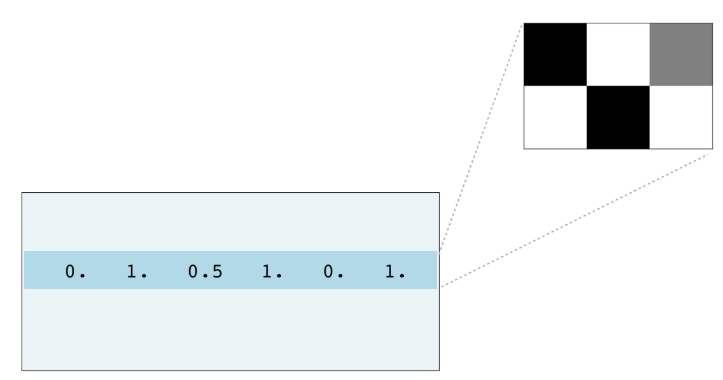

## **Visualizing samples**

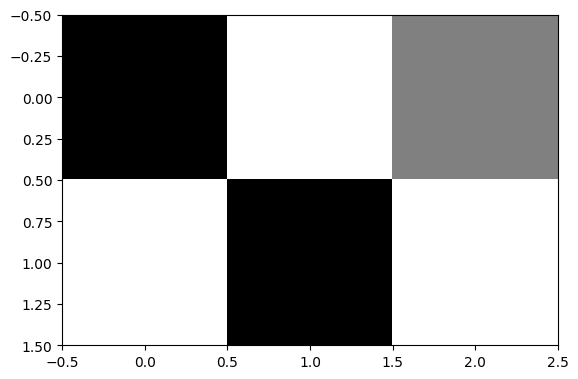

In [22]:
image = [[ 0., 1., 0.5], [ 1., 0., 1. ]]

plt.imshow(image, cmap='gray', interpolation='nearest')
plt.show()




### ***Exercise: NMF learns topics of documents***

You learned when NMF is applied to documents, the components correspond to topics of documents, and the NMF features reconstruct the documents from the topics. Verify this for yourself for the NMF model that you built earlier using the Wikipedia articles. Previously, you saw that the 3rd NMF feature value was high for the articles about actors Anne Hathaway and Denzel Washington. In this exercise, identify the topic of the corresponding NMF component.

The NMF model you built earlier is available as `model`, while `words` is a list of the words that label the columns of the word-frequency array.


* Create a DataFrame `components_df` from `model.components_`, setting `columns=words` so that columns are labeled by the words.

* Print `components_df.shape` to check the dimensions of the DataFrame.

* Use the `.iloc[]` accessor on the DataFrame `components_df` to select row `3`. Assign the result to `component`.

* Call the `.nlargest()` method of `component`, and print the result. This gives the five words with the highest values for that component.

In [ ]:
words = open("wikipedia-vocabulary-utf8.txt").read().split()
print(words[:15])
print(len(words))

['aaron', 'abandon', 'abandoned', 'abandoning', 'abandonment', 'abbas', 'abbey', 'abbreviated', 'abbreviation', 'abc', 'abdomen', 'abdominal', 'abdul', 'abel', 'abilities']
13125


In [ ]:
model.components_.shape

(6, 13125)

In [27]:
words = open("wikipedia-vocabulary-utf8.txt").read().split()

# Create a DataFrame: components_df
components_df = pd.DataFrame(data=model.components_, columns=words)

# Print the shape of the DataFrame
print(components_df.shape, "\n")

# Select row 3: component
component = components_df.iloc[3]

# Print result of nlargest
print(component.nlargest())


(6, 13125) 

film       0.632136
award      0.254846
starred    0.246948
role       0.212885
actress    0.187661
Name: 3, dtype: float64


Take a moment to recognise the topics that the articles about Anne Hathaway and Denzel Washington have in common.

### ***Exercise: Explore the LED digits dataset***

In the following exercises, you'll use NMF to decompose grayscale images into their commonly occurring patterns. Firstly, explore the image dataset and see how it is encoded as an array. You are given 100 images as a 2D array samples, where each row represents a single 13x8 image. The images in your dataset are pictures of a LED digital display.

* Select row `0` of samples and assign the result to digit. For example, to select column `2` of an array `a`, you could use `a[:,2]`. Remember that since samples is a NumPy array, you can't use the `.loc[]` or `iloc[]` accessors to select specific rows or columns.

* Print digit. Notice that it is a 1D array of 0s and 1s.

* Use the `.reshape()` method of `digit` to get a 2D array with shape `(13, 8)`. Assign the result to `bitmap`.

* Print `bitmap`, and notice that the `1`s show the digit `7`!

* Use the `plt.imshow()` function to display `bitmap` as an image.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


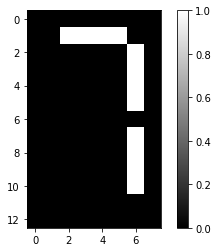

In [ ]:
samples = pd.read_csv('lcd-digits.csv', header=None).values

# Select the 0th row: digit
digit = samples[0, :]

# Print digit
print(digit)

# Reshape digit to a 13x8 array: bitmap
bitmap = digit.reshape(13, 8)

# Print bitmap
print(bitmap)

# Use plt.imshow to display bitmap
plt.imshow(bitmap, cmap='gray', interpolation='nearest')
plt.colorbar()
plt.show()

### ***Exercise: NMF learns the parts of images***

Now use what you've learned about NMF to decompose the digits dataset. You are again given the digit images as a 2D array `samples`. This time, you are also provided with a function `show_as_image()` that displays the image encoded by any 1D array:

```
def show_as_image(sample):
    bitmap = sample.reshape((13, 8))
    plt.figure()
    plt.imshow(bitmap, cmap='gray', interpolation='nearest')
    plt.colorbar()
    plt.show()
```

* Import `NMF` from `sklearn.decomposition`.
* Create an `NMF` instance called `model` with `7` components. (`7` is the number of cells in an LED display).

* Apply the `.fit_transform()` method of `model` to `samples`. Assign the result to `features`.

* To each component of the model (accessed via `model.components_`), apply the `show_as_image()` function to that component inside the loop.

* Assign the row `0` of features to `digit_features`.

* Print `digit_features`.

/usr/local/lib/python3.7/dist-packages/sklearn/decomposition/_nmf.py:294: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  FutureWarning,


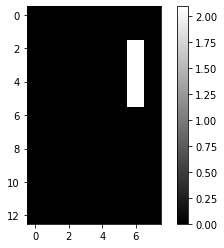

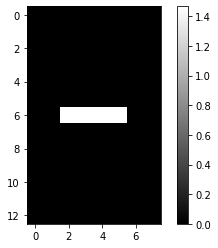

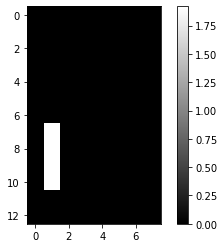

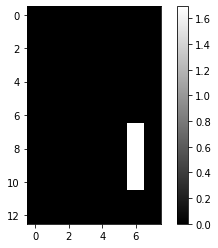

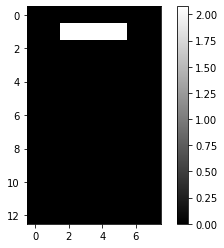

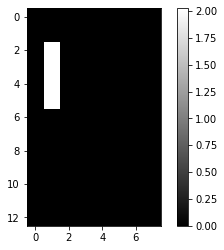

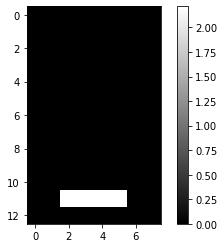

[4.76823559e-01 0.00000000e+00 0.00000000e+00 5.90605054e-01
 4.81559442e-01 0.00000000e+00 7.37551667e-16]


In [ ]:
samples = pd.read_csv('lcd-digits.csv', header=None).values

def show_as_image(sample):
    bitmap = sample.reshape((13, 8))
    plt.figure()
    plt.imshow(bitmap, cmap='gray', interpolation='nearest')
    plt.colorbar()
    plt.show()

from sklearn.decomposition import NMF

# Create an NMF model: model
model = NMF(n_components=7)

# Apply fit_transform to samples: features
features = model.fit_transform(samples)

# Call show_as_image on each component
for component in model.components_:
    show_as_image(component)

# Select the 0th row of features: digit_features
digit_features = features[0, :]

# Print digit_features
print(digit_features)

Take a moment to look through the plots and notice how NMF has expressed the digit as a sum of the components.

### ***Exercise: PCA doesn't learn parts***

Unlike NMF, PCA doesn't learn the parts of things. Its components do not correspond to topics (in the case of documents) or to parts of images, when trained on images. Verify this for yourself by inspecting the components of a PCA model fit to the dataset of LED digit images from the previous exercise. The images are available as a 2D array `samples`. Also available is a modified version of the `show_as_image()` function which colors a pixel red if the value is negative.

* Import `PCA` from `sklearn.decomposition`.
* Create a `PCA` instance called `model` with `7` components.
* Apply the `.fit_transform()` method of model to `samples`. Assign the result to `features`.
* To each component of the model (accessed via `model.components_`), apply the `show_as_image()` function to that component inside the loop.

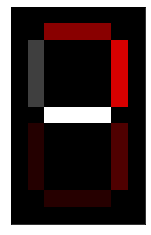

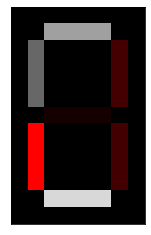

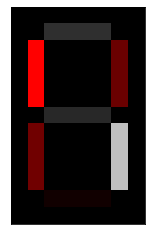

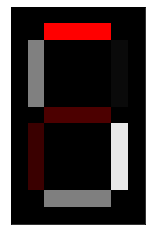

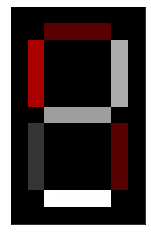

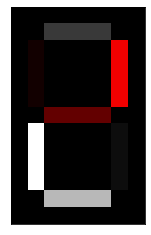

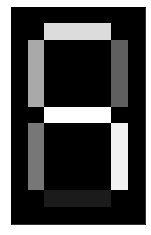

In [ ]:
def show_as_image(vector):
    """
    Given a 1d vector representing an image, display that image in
    black and white.  If there are negative values, then use red for
    that pixel.
    """
    bitmap = vector.reshape((13, 8))  # make a square array
    bitmap /= np.abs(vector).max()  # normalise
    bitmap = bitmap[:,:,np.newaxis]
    rgb_layers = [np.abs(bitmap)] + [bitmap.clip(0)] * 2
    rgb_bitmap = np.concatenate(rgb_layers, axis=-1)
    plt.imshow(rgb_bitmap, interpolation='nearest')
    plt.xticks([])
    plt.yticks([])
    plt.show()

samples = pd.read_csv('lcd-digits.csv', header=None).values

# Import PCA
from sklearn.decomposition import PCA

# Create a PCA instance: model
model = PCA(n_components=7)

# Apply fit_transform to samples: features
features = model.fit_transform(samples)

# Call show_as_image on each component
for component in model.components_:
    show_as_image(component)


Notice that the components of PCA do not represent meaningful parts of images of LED digits!

# **Finding similar articles**

* Recommend similar topics


## ***Apply NMF to the word-frequency array***

In [ ]:
from sklearn.decomposition  import NMF

nmf_features = NMF(n_components=6).fit_transform(articles)

* Similar documents should have similar  NMF features

* Not exactly similar, but point into the same direction

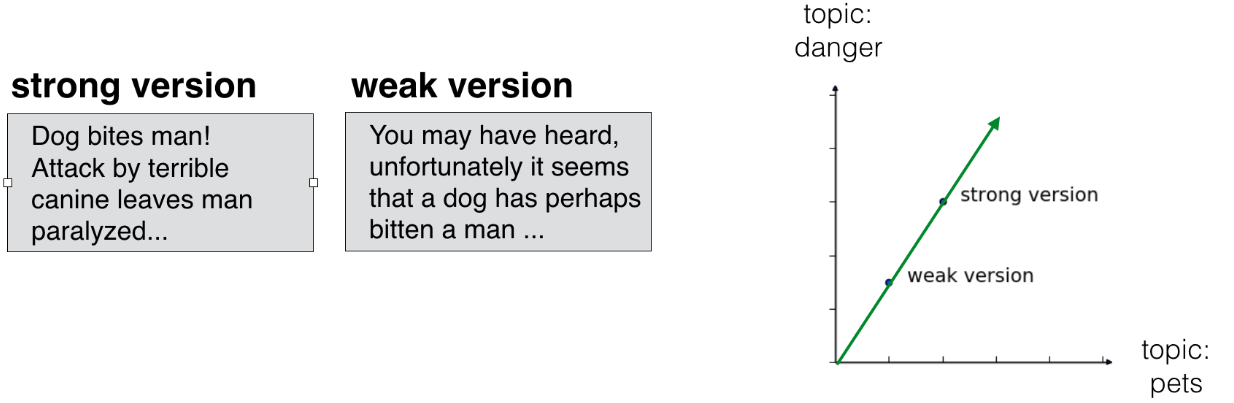

## **Cosine similarities**

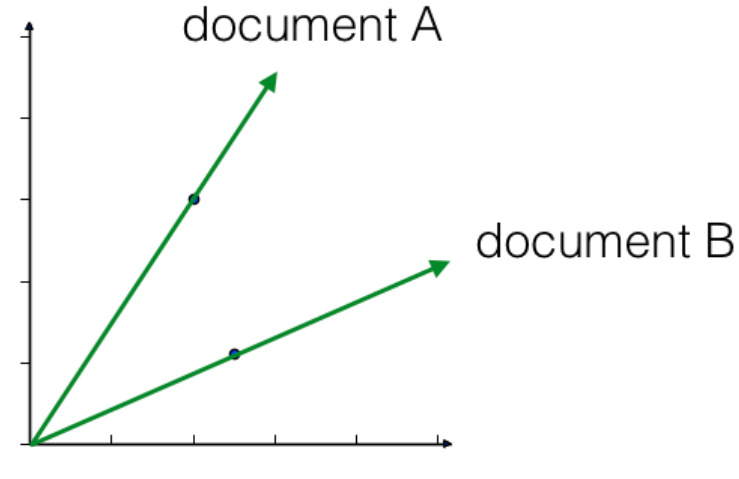


## ***Calculating the cosine similarities***

In [ ]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize

nmf = NMF(n_components=6)
nmf_features = nmf.fit_transform(articles)
norm_features = normalize(nmf_features)

# if has index 23
current_article = norm_features[23,:]
similarities = norm_features.dot(current_article)
print(similarities)



```
[ 0.7150569 0.26349967 ..., 0.20323616 0.05047817]
```



In [ ]:
norm_features = normalize(nmf_features)
df = pd.DataFrame(norm_features, index=titles)
current_article = df.loc['Dog bites man']
similarities = df.dot(current_article)
print(similarities.nlargest())



```
Dog bites man                   1.000000
Hound mauls cat                 0.979946
Pets go wild!                   0.979708
Dachshunds are dangerous        0.949641
Our streets are no longer safe  0.900474
dtype: float64
```



### ***Exercise: Which articles are similar to 'Cristiano Ronaldo'?***

Apply NMF for popular Wikipedia articles, by finding the articles most similar to the article about the footballer Cristiano Ronaldo. The NMF features you obtained earlier are available as `nmf_features`, while `titles` is a list of the article titles.

* Import `normalize` from `sklearn.preprocessing`.
* Apply the `normalize()` function to `nmf_features`. Store the result as `norm_features`.
* Create a DataFrame `df` from `norm_features`, using `titles` as an index.
* Use the **`.loc[]`** accessor of `df` to select the row of `'Cristiano Ronaldo'`. Assign the result to `article`.
* Apply the **`.dot()`** method of `df` to article to calculate the cosine similarity of every row with article.
* Print the result of the **`.nlargest()`** method of `similarities` to display the most similar articles.

In [ ]:
# Perform the necessary imports
import pandas as pd
from sklearn.preprocessing import normalize

# Normalize the NMF features: norm_features
norm_features = normalize(nmf_features)

# Create a DataFrame: df
df = pd.DataFrame(data=norm_features, index=titles)

# Select the row corresponding to 'Cristiano Ronaldo': article
article = df.loc['Cristiano Ronaldo']

# Compute the dot products: similarities
similarities = df.dot(article)

# Display those with the largest cosine similarity
print(similarities.nlargest())

Cristiano Ronaldo                1.000000
Franck Ribéry                    0.999972
Radamel Falcao                   0.999942
Zlatan Ibrahimović               0.999942
France national football team    0.999923
dtype: float64


### ***Exercise: Recommend musical artists part I***

You are given a sparse array artists whose rows correspond to `artists` and whose columns correspond to users. The entries give the number of times each artist was listened to by each user.

In this exercise, build a pipeline and transform the array into normalized NMF features. The first step in the pipeline, `MaxAbsScaler`, transforms the data so that all users have the same influence on the model, regardless of how many different artists they've listened to.


* Import:
  * `NMF` from `sklearn.decomposition`.
  * `Normalizer` and `MaxAbsScaler` from `sklearn.preprocessing`.
  * `make_pipeline` from `sklearn.pipeline`.
* Create an instance of `MaxAbsScaler` called `scaler`.
* Create an `NMF` instance with `20` components called `nmf`.
* Create an instance of `Normalizer` called `normalizer`.
* Create a pipeline called `pipeline` that chains together `scaler`, `nmf`, and `normalizer`.
Apply the `.fit_transform()` method of `pipeline` to `artists`. Assign the result to `norm_features`.


#### Note: artists มี 111 แถว 500 คอลัมน์

In [61]:
# Perform the necessary imports
from sklearn.decomposition import NMF
from sklearn.preprocessing import Normalizer, MaxAbsScaler
from sklearn.pipeline import make_pipeline
from scipy.sparse import csr_matrix

artists = pd.read_csv('artists_tfidf.csv', index_col='Unnamed: 0')
artist_names = artists.index
artists = csr_matrix(artists)

# Create a MaxAbsScaler: scaler
scaler = MaxAbsScaler()

# Create an NMF model: nmf
nmf = NMF(n_components=20)

# Create a Normalizer: normalizer
normalizer = Normalizer()

# Create a pipeline: pipeline
pipeline = make_pipeline(scaler, nmf, normalizer)

# Apply fit_transform to artists: norm_features
norm_features = pipeline.fit_transform(artists)


### ***Recommend musical artists part II***

Use your NMF features from the previous exercise and the cosine similarity to find similar musical artists.  The names of the musical artists are available as the list `artist_names` (มี 111 ชื่อ).


* Create a DataFrame `df` from `norm_features`, using `artist_names` as an `index`.
* Use the `.loc[]` accessor of `df` to select the row of `'Bruce Springsteen'`. Assign the result to `artist`.
* Apply the `.dot()` method of `df` to `artist` to calculate the dot product of every row with artist. Save the result as `similarities`.
* Print the result of the `.nlargest()` method of similarities to display the artists most similar to `'Bruce Springsteen'`.

In [62]:
import pandas as pd

# Create a DataFrame: df
df = pd.DataFrame(data=norm_features, index=artist_names)

# Select row of 'Bruce Springsteen': artist
artist = df.loc['Bruce Springsteen']

# Compute cosine similarities: similarities
similarities = df.dot(artist)

# Display those with highest cosine similarity
print(similarities.nlargest())


Bruce Springsteen    1.000000
Leonard Cohen        0.961683
Neil Young           0.950900
The Beach Boys       0.857050
Van Morrison         0.840510
dtype: float64
